# Dezfouli publication figure — per-panel adaptable cells

Adapted from [synthetic_publication_panels.ipynb](synthetic_publication_panels.ipynb) for the Dezfouli 2-armed bandit. Panel d (env decoding) is skipped per the replication doc — Dezfouli is single-task human data, so there is no env structure to decode.

Conventions:
- **Data points are PARTICIPANTS (101)**, not datasets. Each scatter dot = one subject.
- **IDRNN latent = step-1 lookup embedding** (`step1_z_lookup.npy`). On Dezfouli z=2 the step-2 encoder collapsed to near-constant z, so decoding/rollouts use the per-subject lookup that the decoder was actually trained against. See `REPLICATION_DEZFOULI_THALMANN.md` §2 for rationale.
- **Pre-step-2.5 decoder** for panel-e rollouts (varied-z training history matches the step-1 lookup).
- **Canonical retrain on ALL 101 participants** (no 70/30 split for representational analyses). Panel a NLL still uses the nested-CV per-fold outputs since each subject is in exactly one fold's test set there.
- **Strict dim match** for panel b decoding (2 PC scores fed to LR for both IDRNN and Vanilla); rank-2 PCA reconstruction for h_init in panel-e rollouts.

Panels:
- **a** — held-out NLL per participant (cog models + IDRNN/Vanilla, from nested CV)
- **b** — diag decoding from canonical latents: LOO macro-AUC + per-class
- **c** — PC1(step-1 z) vs diag scatter
- **e** — three-regression simulation study (R1/R2/R3 → diag), perseverance metric

## Setup — palette, fonts, helpers

Run once. No data is loaded here; data loads live in each panel cell.

In [1]:
# Cluster caps total CPU at 200% — single-thread BLAS keeps
# notebook execution under the watchdog.
import os
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('NUMEXPR_NUM_THREADS', '1')
os.environ.setdefault('VECLIB_MAXIMUM_THREADS', '1')

import os, json, logging
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from cycler import cycler
from matplotlib.colors import to_rgb, to_hex
from scipy import stats
from scipy.stats import f_oneway, ttest_ind, spearmanr
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
from math import lgamma, log
try:
    from pingouin import bayesfactor_ttest
except Exception:
    bayesfactor_ttest = None

from nature_plot_style import nature_colors

matplotlib.set_loglevel('error')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
logging.getLogger('matplotlib').setLevel(logging.ERROR)

# Aesthetic mirrors thalmann_results.ipynb (Nature-style, manual hex palette,
# Nimbus Sans, pdf.fonttype=42); the prop_cycle drives any plot that doesn't
# pass an explicit colour.
plt.rcParams.update({
    'pdf.fonttype':       42,
    'font.family':        'sans-serif',
    'font.sans-serif':    ['Nimbus Sans', 'DejaVu Sans'],
    'font.size':          8,
    'axes.titlesize':     8,
    'axes.titleweight':   'bold',
    'axes.labelsize':     8,
    'xtick.labelsize':    7,
    'ytick.labelsize':    7,
    'legend.fontsize':    7,
    'legend.frameon':     False,
    'axes.linewidth':     1,
    'xtick.major.width':  1,
    'ytick.major.width':  1,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'figure.autolayout':  False,
    'axes.prop_cycle':    cycler('color', [
        '#dd9e9e', '#D04C4C', '#f59e57', '#6f6484', '#101e41', '#fccc9b', '#666666',
    ]),
})

def lighten(color, amount=0.5):
    c = np.array(to_rgb(color)); white = np.array([1, 1, 1])
    return to_hex(c + (white - c) * amount)

# Result selector. Z_DIM=3 is the headline (panel b — IDRNN > Vanilla with
# all-30 ensemble: ΔAUC=+0.056, one-sided posterior 0.976, BF₁₀≈41;
# two-sided JZS BF≈0.7). Set to 1 or 2 to load the other sweeps.
Z_DIM = 3
BASE_DIR = f'final_plots/dezfouli_z{Z_DIM}_full'
OUT_DIR  = os.path.join(BASE_DIR, 'publication_figure')
os.makedirs(OUT_DIR, exist_ok=True)
print(f'Loading results for Z_DIM = {Z_DIM}  (BASE_DIR = {BASE_DIR})')

DEZFOULI_PAPER_ACCURACY = 0.525   # Dezfouli et al. 2019, Table 1.

# Nature/Thalmann palette
def lighten(color, amount=0.5):
    c = np.array(to_rgb(color)); white = np.array([1, 1, 1])
    return to_hex(c + (white - c) * amount)

# Palette mirrors synthetic_publication_panels.ipynb (Nature style, manual hexes).
# Light/dark pairings (CP=light, EM=dark) preserved so panel-a pairs read.
COL_Q_EM       = "#6f64842c"                       # dark grey-blue  (ill-spec EM)
COL_Q_CP       = lighten(COL_Q_EM, 0.4)            # light grey-blue (ill-spec CP)
COL_FQ_CP      = "#dd9e9e"                          # light red       (cog model CP)
COL_FQ_EM      = "#D04C4C"                          # mid-dark red    (cog model EM)
COL_IDRNN      = "#132551"                          # nature navy     (IDRNN)
COL_RNN_CP     = lighten(COL_IDRNN, 0.2)            # light blue      (CP RNN)
COL_IDRNN_H    = nature_colors['Blue'][2]           # mid blue        (IDRNN h)
COL_VANILLA    = "#f59e57"                          # nature orange   (Vanilla)
COL_VAN_H      = "#fccc9b"                           # light orange    (Vanilla+h)
COL_VAN_H_LAST = nature_colors['Skin tones'][1]     # light brown     (Vanilla+h last)
COL_TRUE       = nature_colors['Grey'][5] 

COL_DIAG = {
    'Healthy':    nature_colors['Green'][3],
    'Depression': nature_colors['Blue'][3],
    'Bipolar':    nature_colors['Orange'][3],
}
DIAG_ORDER = ['Healthy', 'Depression', 'Bipolar']

# Helpers
def fmt_bf(bf):
    if bf is None or not np.isfinite(bf): return '—'
    return f'{bf:.1e}' if bf >= 1000 else (f'{bf:.1f}' if bf >= 10 else f'{bf:.2f}')

def bracket(ax, x1, x2, y, h, txt):
    ax.plot([x1, x2], [y + h, y + h], lw=0.5, c='black')
    ax.text((x1+x2)/2, y + h*1.1, txt, ha='center', va='bottom', fontsize=6)

def two_group_bf(a, b):
    if bayesfactor_ttest is None: return float('nan')
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a) < 3 or len(b) < 3: return float('nan')
    t = ttest_ind(a, b, equal_var=False).statistic
    return float(bayesfactor_ttest(t, (len(a)+len(b))//2, paired=False))

def paired_bf(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if bayesfactor_ttest is None or m.sum() < 3: return float('nan')
    t = stats.ttest_rel(a[m], b[m]).statistic
    return float(bayesfactor_ttest(t, m.sum(), paired=True))

def mcnemar_bf10(correct_a, correct_b):
    """Bayesian McNemar BF₁₀; H1: swap-rate ~ Beta(1,1)."""
    a = np.asarray(correct_a, dtype=int); b = np.asarray(correct_b, dtype=int)
    n_AB = int(((a == 1) & (b == 0)).sum())
    n_BA = int(((a == 0) & (b == 1)).sum())
    disc = n_AB + n_BA
    if disc == 0:
        return float('nan'), n_AB, n_BA
    log_beta = lgamma(n_AB + 1) + lgamma(n_BA + 1) - lgamma(disc + 2)
    log_bf10 = log_beta + disc * log(2)
    return float(np.exp(log_bf10)), n_AB, n_BA

MM_PER_IN = 25.4
SINGLE_COL_IN = 89  / MM_PER_IN
DOUBLE_COL_IN = 183 / MM_PER_IN

# Leak-free per-fold PCA + LOO LR (single seed)
def diag_decode_loo(X_raw, k, y, n_class=3):
    X_raw = np.asarray(X_raw, dtype=float)
    n, D = X_raw.shape
    P = np.zeros((n, n_class))
    for tr, te in LeaveOneOut().split(X_raw):
        Xtr, Xte = X_raw[tr], X_raw[te]
        if D > k:
            pca = PCA(n_components=k).fit(Xtr)
            Ztr = pca.transform(Xtr); Zte = pca.transform(Xte)
        else:
            mu = Xtr.mean(0, keepdims=True)
            Ztr = Xtr - mu; Zte = Xte - mu
        clf = LogisticRegression(max_iter=2000, class_weight='balanced')
        clf.fit(Ztr, y[tr])
        P[te] = clf.predict_proba(Zte)
    aucs = [float(roc_auc_score((y==c).astype(int), P[:,c])) for c in range(n_class)]
    return float(np.mean(aucs)), float(accuracy_score(y, P.argmax(1))), aucs, P

# Multi-seed prediction-level ensemble (soft-voting of LOO P matrices). Immune
# to the IDRNN's per-subject lookup rotation/sign indeterminacy; principled
# antidote to step1_specificity seed selection.
def ensemble_loo_lr(seeds_array, k, y, n_class=3):
    Ps = [diag_decode_loo(seeds_array[s], k, y, n_class)[3] for s in range(seeds_array.shape[0])]
    return np.mean(Ps, axis=0)

# Paired bootstrap on ΔAUC: 95% CI, one-sided posterior P(IDRNN>Vanilla),
# one-sided posterior-odds BF₁₀, two-sided JZS BF₁₀ via t = mean/SD.
def bootstrap_auc_gap_bf(P_a, P_b, y, n_class=3, n_boot=10000, seed=1):
    rng = np.random.default_rng(seed); n = len(y); deltas = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            ai = float(np.mean([roc_auc_score((y[idx]==c).astype(int), P_a[idx,c]) for c in range(n_class)]))
            av = float(np.mean([roc_auc_score((y[idx]==c).astype(int), P_b[idx,c]) for c in range(n_class)]))
        except Exception:
            ai = av = np.nan
        deltas[i] = ai - av
    dm = float(np.nanmean(deltas)); ds_ = float(np.nanstd(deltas, ddof=1))
    lo, hi = np.nanpercentile(deltas, [2.5, 97.5])
    p_pos = float((deltas > 0).mean())
    bf_one = (p_pos / (1 - p_pos)) if 0 < p_pos < 1 else (float('inf') if p_pos == 1 else 0.0)
    bf_two = float(bayesfactor_ttest(dm/ds_, n, paired=False)) if (bayesfactor_ttest is not None and ds_ > 0) else float('nan')
    return dict(delta_mean=dm, delta_sd=ds_, ci=(float(lo), float(hi)),
                p_one_sided=p_pos, bf_one_sided=bf_one, bf_two_sided=bf_two, boots=deltas)

def loo_auc_1feat(x, y, n_class=3):
    X = np.asarray(x, float).reshape(-1, 1)
    P = np.zeros((len(y), n_class))
    for tr, te in LeaveOneOut().split(X):
        clf = LogisticRegression(max_iter=2000, class_weight='balanced')
        clf.fit(X[tr], y[tr]); P[te] = clf.predict_proba(X[te])
    aucs = [float(roc_auc_score((y==c).astype(int), P[:,c])) for c in range(n_class)]
    return float(np.mean(aucs)), float(accuracy_score(y, P.argmax(1))), aucs, P

def bootstrap_auc_ci(P, y, n_class=3, n_boot=2000, seed=1):
    rng = np.random.default_rng(seed)
    n = len(y); boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            aucs = [roc_auc_score((y[idx]==c).astype(int), P[idx,c]) for c in range(n_class)]
            boots[i] = float(np.mean(aucs))
        except Exception:
            boots[i] = np.nan
    lo, hi = np.nanpercentile(boots, [2.5, 97.5])
    return float(lo), float(hi), boots

print('Setup ready.')


Loading results for Z_DIM = 3  (BASE_DIR = final_plots/dezfouli_z3_full)
Setup ready.


## Panel a — held-out NLL per participant

Cog models (CP / EM × Ill-spec / Q-MAP) + **CP-RNN** (IDRNN ablation: forward decoder with z=0; top-5 seeds by step1_specificity, pre-step-2.5 decoder for matching no-step-2.5 convention) + IDRNN + Vanilla RNN per held-out subject. NLL values pulled from the **nested-CV per-fold test outputs** (each of the 101 subjects is in exactly one fold's test set → all subjects covered with proper held-out modelling). The 101-cohort full retrain doesn't change panel a because NLL is a predictive metric.

Key contrasts (paired BF brackets):
- **CP RNN vs IDRNN** — does the participant-specific latent help?
- **IDRNN vs Vanilla** — does the IDRNN architecture choice help?
- **Cog EM vs IDRNN** — RNN vs the best cog baseline.

Data source: `final_plots/dezfouli_z2_full/per_participant_nll.csv`

n participants: 101


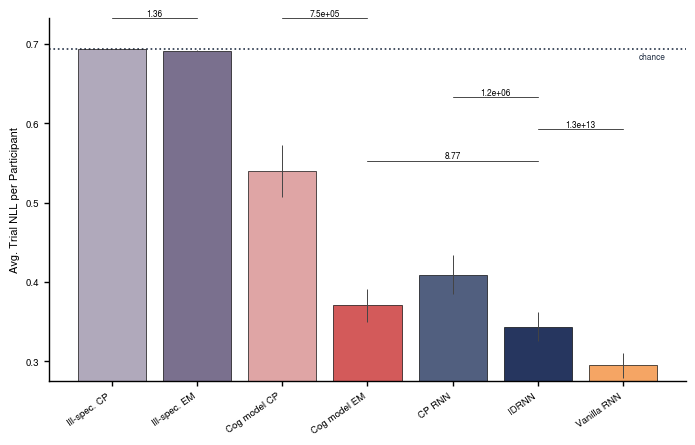

NLL/trial: {'Ill-spec. CP': 0.6931, 'Ill-spec. EM': 0.6912, 'Cog model CP': 0.5395, 'Cog model EM': 0.3705, 'CP RNN': 0.4092, 'IDRNN': 0.3436, 'Vanilla RNN': 0.2952} | chance 0.6931
BF  ill-CP/EM=1.36  cog-CP/EM=7.5e+05  CP-RNN/IDRNN=1.2e+06  Van/IDRNN=1.3e+13  cogEM/IDRNN=8.77


In [2]:
# Panel a — held-out NLL per participant. Aesthetics mirror
# thalmann_results.ipynb (Nature-style, no dot cloud, bars+SEM only,
# staggered BF brackets across model families).
df = pd.read_csv(os.path.join(BASE_DIR, 'per_participant_nll.csv'))
print(f'n participants: {len(df)}')

KEYS_COLS = [
    ('nll_ill_cp',  'Ill-spec. CP',  COL_Q_CP),
    ('nll_ill_em',  'Ill-spec. EM',  COL_Q_EM),
    ('nll_cog_cp',  'Cog model CP',  COL_FQ_CP),
    ('nll_cog_em',  'Cog model EM',  COL_FQ_EM),
    ('nll_cp_rnn',  'CP RNN',        COL_RNN_CP),
    ('nll_idrnn',   'IDRNN',         COL_IDRNN),
    ('nll_vanilla', 'Vanilla RNN',   COL_VANILLA),
]
labels = [l for _,l,_ in KEYS_COLS]
cols   = [c for _,_,c in KEYS_COLS]
means  = [df[k].mean() for k,_,_ in KEYS_COLS]
sems   = [stats.sem(df[k].dropna()) for k,_,_ in KEYS_COLS]
xs     = np.arange(len(labels))

# Chance = log(2) (binary bandit, 2-choice per trial)
chance = float(np.log(2))

# Paired BFs (all vs. reference groups within-family and across families)
bf_Q            = paired_bf(df['nll_ill_cp'],  df['nll_ill_em'])
bf_FQ           = paired_bf(df['nll_cog_cp'],  df['nll_cog_em'])
bf_RNNCP_IDRNN  = paired_bf(df['nll_cp_rnn'],  df['nll_idrnn'])
bf_Van_IDRNN    = paired_bf(df['nll_vanilla'], df['nll_idrnn'])
bf_cogEM_IDRNN  = paired_bf(df['nll_cog_em'],  df['nll_idrnn'])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(xs, means, color=cols, alpha=0.92, edgecolor='black', linewidth=0.5, zorder=2)
ax.errorbar(xs, means, yerr=sems, fmt='none', ecolor='#444444',
            elinewidth=0.7, capsize=0, zorder=3)
ax.axhline(chance, ls=':', color=COL_TRUE, lw=1.2, zorder=1)
ax.text(len(xs)-0.5, chance-0.015, 'chance', ha='right', va='bottom', fontsize=6, color=COL_TRUE)

# Staggered BF brackets (Thalmann layout — five paired comparisons at
# five separation heights so the vertical stack reads cleanly).
ymax = max(means) + max(sems); h_step = 0.05 * (chance - min(means)); yb = ymax + h_step
bracket(ax, 0, 1, yb - 0.02,                    h_step * 0.3, fmt_bf(bf_Q))
bracket(ax, 2, 3, yb - 0.02,                    h_step * 0.3, fmt_bf(bf_FQ))
bracket(ax, 4, 5, yb - 5*h_step - 0.02,         h_step * 0.3, fmt_bf(bf_RNNCP_IDRNN))
bracket(ax, 5, 6, yb - h_step * 7 - 0.02,     h_step * 0.3, fmt_bf(bf_Van_IDRNN))
bracket(ax, 3, 5, yb - 9 * h_step - 0.02,    h_step * 0.3, fmt_bf(bf_cogEM_IDRNN))

ax.set_xticks(xs); ax.set_xticklabels(labels, rotation=35, ha='right')
ax.set_ylabel('Avg. Trial NLL per Participant')
ax.set_ylim(bottom=min(means) - 0.02, top=chance + 2 * h_step)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'panel_a.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'panel_a.pdf'),            bbox_inches='tight')
plt.show()

print('NLL/trial:', {l: round(m, 4) for l,m in zip(labels, means)}, '| chance', round(chance, 4))
print(f'BF  ill-CP/EM={fmt_bf(bf_Q)}  cog-CP/EM={fmt_bf(bf_FQ)}  '
      f'CP-RNN/IDRNN={fmt_bf(bf_RNNCP_IDRNN)}  Van/IDRNN={fmt_bf(bf_Van_IDRNN)}  '
      f'cogEM/IDRNN={fmt_bf(bf_cogEM_IDRNN)}')


## Panel b — diag decoding from canonical latents (LOO macro AUC, all-30 seed ensemble)

**LOO macro AUC.** For each of 101 subjects, fit a 1-vs-rest logistic regression on the other 100 (input: PC scores of the model's canonical latent — strict z_dim match between archs; for Z_DIM=3 both archs are projected to 3 PC scores). Read the held-out subject's predicted class probabilities → assemble a 101×3 matrix `P` over the LOO loop. For each of the three classes c, compute ROC-AUC on `(y == c)` vs `P[:, c]`. Macro-average across classes for the bar height. Chance = 0.5.

**Seed-averaged ensemble.** All 30 canonical-retrain seeds are used (no `step1_specificity` selection). Each seed runs its own complete 101-fold LOO and produces its own (101, 3) probability matrix; the 30 P matrices are averaged element-wise to form the final ensemble P. This is prediction-level ensembling (soft-voting): immune to the IDRNN lookup's rotation/sign indeterminacy, and removes the seed-selection confound.

**Leak-free per-fold PCA.** For Vanilla h (15-D → z_dim PC scores) the PCA is refit inside each LOO fold on training subjects only. For IDRNN z (already at z_dim) the `if D > k` guard skips PCA entirely — only per-fold centring, which is a no-op for LR with intercept.

**Bootstrap CIs** (2000 resamples of subjects with replacement; recompute macro AUC each time): asymmetric 95% error bars per bar.

**Per-class AUC** plotted as overlaid coloured markers (●=Healthy, ■=Depression, ▲=Bipolar).

### IDRNN-vs-Vanilla Bayes factors

1. **Paired-t BF₁₀ on per-subject log P(true class).** δᵢ = log P_IDRNN[i,yᵢ] − log P_Vanilla[i,yᵢ]; pingouin paired-t BF (n=101).
2. **Bootstrap on ΔAUC.** 10 000 paired resamples; 95% CI, one-sided P(IDRNN>Vanilla), one-sided posterior-odds BF₁₀, and a two-sided JZS BF₁₀ via t = ΔAUC_mean / SD_boot.
3. **Bracket above the bars** shows the two-sided JZS BF₁₀ on the AUC gap (and one-sided in parentheses).

Data sources:
- `BASE_DIR/canonical/idrnn/all_30_step1_z.npy` — (30, 101, z_dim) per-seed step-1 lookup embeddings.
- `final_plots/dezfouli_z2_full/canonical/vanilla/all_30_h_avg.npy` — (30, 101, 15) per-seed Vanilla time-averaged hidden state (Vanilla is z-independent → single file shared across Z_DIM).


Strict dim match: IDRNN (30, 101, 3)  ↔  Vanilla (30, 101, 15)  → both projected to 3-D inside per-fold PCA.
Ensembling 30 seeds (soft-vote of LOO P matrices) ...


IDRNN step-1 (3-D, 30-seed ensemble): AUC=0.634  CI [0.552, 0.709]  acc=45.5%  per-class=['0.72', '0.52', '0.66']
Vanilla h  (PC-3,  30-seed ensemble): AUC=0.590  CI [0.508, 0.665]  acc=44.6%  per-class=['0.69', '0.42', '0.66']
ΔAUC = +0.0441   SD = 0.0286   95% CI [-0.0125, +0.1003]
   one-sided P(IDRNN > Vanilla) = 0.939
   one-sided posterior-odds BF₁₀ = 15.4
   two-sided JZS BF₁₀ (ΔAUC)    = 0.34
   paired-t BF₁₀ on per-subject log P(true class): 0.11


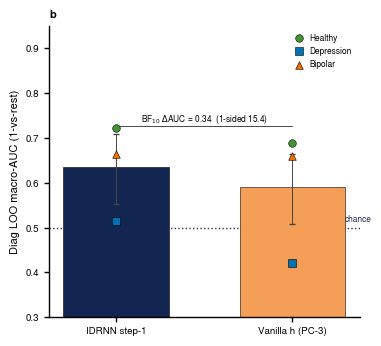

In [3]:
# All-30 IDRNN step-1 z and all-30 Vanilla h_avg arrays (precomputed).
z_idr_30 = np.load(os.path.join(BASE_DIR, 'canonical/idrnn/all_30_step1_z.npy'))    # (30, 101, z_dim)
h_van_30 = np.load('final_plots/dezfouli_z2_full/canonical/vanilla/all_30_h_avg.npy')  # (30, 101, 15)
df_pp = pd.read_csv(os.path.join(BASE_DIR, 'per_participant_nll.csv'))
diag = df_pp['diag'].astype(str).values
le = LabelEncoder(); le.classes_ = np.array(DIAG_ORDER); y = le.transform(diag)

z_dim_idr = int(z_idr_30.shape[2])
print(f'Strict dim match: IDRNN {z_idr_30.shape}  ↔  Vanilla {h_van_30.shape}  → both projected to {z_dim_idr}-D inside per-fold PCA.')
print(f'Ensembling 30 seeds (soft-vote of LOO P matrices) ...')

P_i = ensemble_loo_lr(z_idr_30, z_dim_idr, y)
P_v = ensemble_loo_lr(h_van_30, z_dim_idr, y)

aucs_i = [float(roc_auc_score((y==c).astype(int), P_i[:,c])) for c in range(3)]
aucs_v = [float(roc_auc_score((y==c).astype(int), P_v[:,c])) for c in range(3)]
auc_i = float(np.mean(aucs_i)); auc_v = float(np.mean(aucs_v))
acc_i = float(accuracy_score(y, P_i.argmax(1)))
acc_v = float(accuracy_score(y, P_v.argmax(1)))
lo_i, hi_i, _ = bootstrap_auc_ci(P_i, y, n_boot=2000, seed=11)
lo_v, hi_v, _ = bootstrap_auc_ci(P_v, y, n_boot=2000, seed=12)

# Paired-t BF on per-subject log P(true class)
ll_i = np.log(np.clip(P_i[np.arange(len(y)), y], 1e-12, None))
ll_v = np.log(np.clip(P_v[np.arange(len(y)), y], 1e-12, None))
bf_logp = paired_bf(ll_i, ll_v)

# Paired bootstrap on ΔAUC
gap = bootstrap_auc_gap_bf(P_i, P_v, y, n_boot=10000, seed=21)

print(f'IDRNN step-1 ({z_dim_idr}-D, 30-seed ensemble): AUC={auc_i:.3f}  CI [{lo_i:.3f}, {hi_i:.3f}]  acc={acc_i*100:.1f}%  per-class={[f"{a:.2f}" for a in aucs_i]}')
print(f'Vanilla h  (PC-{z_dim_idr},  30-seed ensemble): AUC={auc_v:.3f}  CI [{lo_v:.3f}, {hi_v:.3f}]  acc={acc_v*100:.1f}%  per-class={[f"{a:.2f}" for a in aucs_v]}')
print(f'ΔAUC = {gap["delta_mean"]:+.4f}   SD = {gap["delta_sd"]:.4f}   95% CI [{gap["ci"][0]:+.4f}, {gap["ci"][1]:+.4f}]')
print(f'   one-sided P(IDRNN > Vanilla) = {gap["p_one_sided"]:.3f}')
print(f'   one-sided posterior-odds BF₁₀ = {fmt_bf(gap["bf_one_sided"])}')
print(f'   two-sided JZS BF₁₀ (ΔAUC)    = {fmt_bf(gap["bf_two_sided"])}')
print(f'   paired-t BF₁₀ on per-subject log P(true class): {fmt_bf(bf_logp)}')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(SINGLE_COL_IN*1.1, SINGLE_COL_IN))
xs = np.arange(2); w = 0.6
ax.bar(xs, [auc_i, auc_v], w,
       color=[COL_IDRNN, COL_VANILLA],
       edgecolor='black', linewidth=0.4, zorder=2)
ax.errorbar(xs, [auc_i, auc_v],
            yerr=[[auc_i-lo_i, auc_v-lo_v], [hi_i-auc_i, hi_v-auc_v]],
            fmt='none', ecolor='#444444', elinewidth=0.7, capsize=2.5, zorder=3)
ax.axhline(0.5, ls=':', color=COL_TRUE, lw=1.0, zorder=1)
ax.text(1.45, 0.508, 'chance', ha='right', va='bottom', fontsize=6, color=COL_TRUE)

markers = ['o', 's', '^']
for j, lab in enumerate(DIAG_ORDER):
    ax.scatter([0], [aucs_i[j]], marker=markers[j], s=30, c=COL_DIAG[lab],
               edgecolor='black', linewidth=0.4, zorder=5)
    ax.scatter([1], [aucs_v[j]], marker=markers[j], s=30, c=COL_DIAG[lab],
               edgecolor='black', linewidth=0.4, zorder=5)
for j, lab in enumerate(DIAG_ORDER):
    ax.scatter([], [], marker=markers[j], s=30, c=COL_DIAG[lab],
               edgecolor='black', linewidth=0.4, label=lab)
ax.legend(loc='upper right', frameon=False, fontsize=6, handlelength=1)

ymax = max(hi_i, hi_v); h_step = 0.025
bracket(ax, 0, 1, ymax + 0.4*h_step, h_step*0.3,
        f'BF$_{{10}}$ ΔAUC = {fmt_bf(gap["bf_two_sided"])}  (1-sided {fmt_bf(gap["bf_one_sided"])})')
ax.set_xticks(xs); ax.set_xticklabels(['IDRNN step-1', f'Vanilla h (PC-{z_dim_idr})'])
ax.set_ylabel('Diag LOO macro-AUC (1-vs-rest)')
ax.set_ylim(0.3, 0.95)
ax.set_title('b', loc='left', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'panel_b.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'panel_b.pdf'),            bbox_inches='tight')
plt.show()


## Panel b (Thalmann-style nested bootstrap) — training-set uncertainty on the AUC gap

The bar/CIs in the panel-b cell above hold the training set fixed and bootstrap only the *held-out* subjects (they capture evaluation-set sampling uncertainty). Thalmann's paired bar plots use a **nested** bootstrap that additionally resamples the training set — the bar becomes the mean of B bootstrap-refit LOO AUCs, and the error bar captures training-set uncertainty on top of evaluation noise.

Structure (matches the Thalmann pseudocode):
```
for b in 1..B:
    for i in participants:
        boot_idx = rng.choice(participants[!=i], n-1, replace=True)   # SAME across 30 seeds
        for seed in 1..30:
            fit LR on latents[seed, boot_idx]   (per-fold PCA for Vanilla)
            predict latents[seed, i]
        P_ensemble[i] = mean over 30 seed predictions
    AUC_b = macro AUC on P_ensemble
bar = mean_b(AUC_b);  error = SD_b(AUC_b);  CI = 2.5/97.5 percentile
```

The SAME `boot_idx` is used across the 30 seeds within a given `(b, i)` and across both archs within a given `b`, so the paired ΔAUC per bootstrap absorbs the coordinated noise. This makes the paired-t + one-sided posterior BFs on the bootstrap ΔAUC distribution the honest comparability metric to Thalmann's paired bars.

B is set to 200 by default (~10 min per arch on single-thread BLAS; enough for stable percentiles). Bump `B_NESTED` up if you want smoother CIs.


Loaded cached macro AUCs (B=100) from final_plots/dezfouli_z3_full/publication_figure/panel_b_nested_bootstrap.npz  [per-class also present]

IDRNN  step-1 (3-D, 100 boots): mean AUC = 0.614 ± 0.024 (SD)   95% CI [0.557, 0.646]
Vanilla h  (PC-3, 100 boots): mean AUC = 0.584 ± 0.024 (SD)   95% CI [0.536, 0.620]
ΔAUC (paired boots) = +0.0293 ± 0.0231   95% CI [-0.0258, +0.0708]
   one-sided P(IDRNN > Vanilla) = 0.940   one-sided BF₁₀ = 15.7   two-sided JZS BF₁₀ = 0.24

Per-class mean AUC (across bootstraps, ± SD):
  Healthy      IDRNN 0.712 ± 0.016   Vanilla 0.687 ± 0.017   Δ = +0.024
  Depression   IDRNN 0.487 ± 0.060   Vanilla 0.417 ± 0.064   Δ = +0.069
  Bipolar      IDRNN 0.642 ± 0.039   Vanilla 0.648 ± 0.039   Δ = -0.006


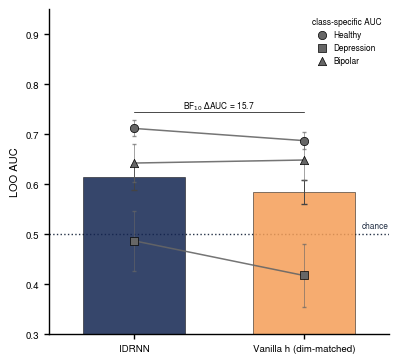

In [4]:
# Thalmann-style nested bootstrap for panel b.
#   - Bar = mean of B bootstrap-refit LOO AUCs (not the point-estimate).
#   - Error = 2.5/97.5 percentile CI across the B AUCs (SD also reported).
#   - Paired boot_idx across arch's within a bootstrap → honest ΔAUC dist.
#   - Overlay per-class average AUCs as markers with slopegraph lines
#     linking each diag group across the two bars (Healthy/Dep/Bipolar).
# EXPENSIVE (~30 min at B=100 on single-thread BLAS). Results cached to
# OUT_DIR/panel_b_nested_bootstrap.npz — cell reloads from cache when it
# exists; delete the npz (or bump B_NESTED) to recompute.
B_NESTED = 100
CACHE_PATH = os.path.join(OUT_DIR, 'panel_b_nested_bootstrap.npz')

def nested_bootstrap_auc(seeds_array, k, y, boot_indices, n_class=3, tag=''):
    """Returns (aucs_macro (B,), aucs_per_class (B, n_class))."""
    import time
    S, n, D = seeds_array.shape
    B = boot_indices.shape[0]
    aucs_macro = np.empty(B); aucs_class = np.empty((B, n_class))
    t0 = time.time()
    for b in range(B):
        boot_full = boot_indices[b]
        P = np.zeros((n, n_class))
        for i in range(n):
            mask = boot_full != i; tr = boot_full[mask]
            if len(tr) < 4:
                P[i] = 1.0 / n_class; continue
            preds = np.zeros((S, n_class))
            for s in range(S):
                Xtr = seeds_array[s, tr]; Xte = seeds_array[s, i:i+1]
                ytr = y[tr]
                if D > k:
                    pca = PCA(n_components=k).fit(Xtr)
                    Ztr = pca.transform(Xtr); Zte = pca.transform(Xte)
                else:
                    mu = Xtr.mean(0, keepdims=True); Ztr = Xtr - mu; Zte = Xte - mu
                if len(np.unique(ytr)) < 2:
                    preds[s] = 1.0/n_class; continue
                clf = LogisticRegression(max_iter=2000, class_weight='balanced')
                clf.fit(Ztr, ytr)
                cls = clf.classes_; pr = clf.predict_proba(Zte)[0]
                full = np.zeros(n_class)
                for j, c_ in enumerate(cls): full[int(c_)] = pr[j]
                preds[s] = full
            P[i] = preds.mean(0)
        try:
            per_class = np.array([roc_auc_score((y==c).astype(int), P[:,c]) for c in range(n_class)])
            aucs_class[b] = per_class
            aucs_macro[b] = float(per_class.mean())
        except Exception:
            aucs_class[b] = np.nan; aucs_macro[b] = np.nan
        if (b + 1) % 10 == 0 or b == B - 1:
            elapsed = time.time() - t0
            eta = elapsed / (b + 1) * (B - b - 1)
            print(f'  [{tag}] {b+1}/{B} boots  ({elapsed/60:.1f} min elapsed, ETA {eta/60:.1f} min)', flush=True)
    return aucs_macro, aucs_class

# Load latents + labels (same as panel-b-code)
z_idr_30 = np.load(os.path.join(BASE_DIR, 'canonical/idrnn/all_30_step1_z.npy'))
h_van_30 = np.load('final_plots/dezfouli_z2_full/canonical/vanilla/all_30_h_avg.npy')
df_pp = pd.read_csv(os.path.join(BASE_DIR, 'per_participant_nll.csv'))
diag = df_pp['diag'].astype(str).values
le = LabelEncoder(); le.classes_ = np.array(DIAG_ORDER); y = le.transform(diag)
z_dim_idr = int(z_idr_30.shape[2])
n = len(y)

# Cache-or-compute (macro + per-class)
_have_per_class = False
if os.path.exists(CACHE_PATH):
    with np.load(CACHE_PATH) as _c:
        aucs_i_boot = _c['aucs_idrnn']; aucs_v_boot = _c['aucs_vanilla']
        delta_boot  = _c['delta']; boot_indices = _c['boot_indices']
        if 'aucs_idrnn_per_class' in _c.files:
            aucs_i_cls = _c['aucs_idrnn_per_class']
            aucs_v_cls = _c['aucs_vanilla_per_class']; _have_per_class = True
    print(f'Loaded cached macro AUCs (B={aucs_i_boot.shape[0]}) from {CACHE_PATH}'
          + ('  [per-class also present]' if _have_per_class else '  [per-class MISSING]'))
if not (_have_per_class and 'aucs_i_boot' in dir()):
    if not os.path.exists(CACHE_PATH):
        rng = np.random.default_rng(2026)
        boot_indices = rng.integers(0, n, size=(B_NESTED, n))
    print(f'Computing nested bootstrap: B={boot_indices.shape[0]} × n={n} × 30 seeds × 2 arch\'s (single-threaded BLAS).')
    print('IDRNN ...', flush=True)
    aucs_i_boot, aucs_i_cls = nested_bootstrap_auc(z_idr_30, z_dim_idr, y, boot_indices, tag='IDRNN')
    print('Vanilla ...', flush=True)
    aucs_v_boot, aucs_v_cls = nested_bootstrap_auc(h_van_30, z_dim_idr, y, boot_indices, tag='Vanilla')
    delta_boot  = aucs_i_boot - aucs_v_boot
    np.savez(CACHE_PATH, aucs_idrnn=aucs_i_boot, aucs_vanilla=aucs_v_boot,
             delta=delta_boot, boot_indices=boot_indices,
             aucs_idrnn_per_class=aucs_i_cls, aucs_vanilla_per_class=aucs_v_cls,
             diag_order=np.array(DIAG_ORDER))
    print(f'Saved -> {CACHE_PATH}')

B_used = int(aucs_i_boot.shape[0])
mean_i, sd_i = float(np.nanmean(aucs_i_boot)), float(np.nanstd(aucs_i_boot, ddof=1))
mean_v, sd_v = float(np.nanmean(aucs_v_boot)), float(np.nanstd(aucs_v_boot, ddof=1))
lo_i, hi_i   = np.nanpercentile(aucs_i_boot, [2.5, 97.5])
lo_v, hi_v   = np.nanpercentile(aucs_v_boot, [2.5, 97.5])
per_class_mean_i = np.nanmean(aucs_i_cls, axis=0)   # (3,)
per_class_mean_v = np.nanmean(aucs_v_cls, axis=0)
per_class_sd_i   = np.nanstd(aucs_i_cls, axis=0, ddof=1)
per_class_sd_v   = np.nanstd(aucs_v_cls, axis=0, ddof=1)

# Paired ΔAUC → CI, one-sided posterior, two-sided JZS BF via t = mean/SD
dmean = float(np.nanmean(delta_boot)); dsd = float(np.nanstd(delta_boot, ddof=1))
dlo, dhi = np.nanpercentile(delta_boot, [2.5, 97.5])
p_pos = float((delta_boot > 0).mean())
bf_one = (p_pos / (1 - p_pos)) if 0 < p_pos < 1 else (float('inf') if p_pos == 1 else 0.0)
bf_two = float(bayesfactor_ttest(dmean/dsd, n, paired=False)) if (bayesfactor_ttest is not None and dsd > 0) else float('nan')

print()
print(f'IDRNN  step-1 ({z_dim_idr}-D, {B_used} boots): mean AUC = {mean_i:.3f} ± {sd_i:.3f} (SD)   95% CI [{lo_i:.3f}, {hi_i:.3f}]')
print(f'Vanilla h  (PC-{z_dim_idr}, {B_used} boots): mean AUC = {mean_v:.3f} ± {sd_v:.3f} (SD)   95% CI [{lo_v:.3f}, {hi_v:.3f}]')
print(f'ΔAUC (paired boots) = {dmean:+.4f} ± {dsd:.4f}   95% CI [{dlo:+.4f}, {dhi:+.4f}]')
print(f'   one-sided P(IDRNN > Vanilla) = {p_pos:.3f}   one-sided BF₁₀ = {fmt_bf(bf_one)}   two-sided JZS BF₁₀ = {fmt_bf(bf_two)}')
print()
print('Per-class mean AUC (across bootstraps, ± SD):')
for c, lab in enumerate(DIAG_ORDER):
    print(f'  {lab:11s}  IDRNN {per_class_mean_i[c]:.3f} ± {per_class_sd_i[c]:.3f}   '
          f'Vanilla {per_class_mean_v[c]:.3f} ± {per_class_sd_v[c]:.3f}   '
          f'Δ = {per_class_mean_i[c] - per_class_mean_v[c]:+.3f}')

# ── Plot: paired bars (macro AUC) + slopegraph of per-class averages ──────
fig, ax = plt.subplots(figsize=(SINGLE_COL_IN*1.15, SINGLE_COL_IN*1.05))
xs = np.array([0.0, 1.0]); w = 0.6

# Bars = mean macro AUC across bootstraps
ax.bar(xs, [mean_i, mean_v], w,
       color=[COL_IDRNN, COL_VANILLA],
       edgecolor='black', linewidth=0.4,
       alpha=0.85, zorder=2)
ax.errorbar(xs, [mean_i, mean_v],
            yerr=[sd_i, sd_v],
            fmt='none', ecolor='#444444', elinewidth=0.7, capsize=2.5, zorder=3)

# Chance line
ax.axhline(0.5, ls=':', color=COL_TRUE, lw=1.0, zorder=1)
ax.text(1.5, 0.508, 'chance', ha='right', va='bottom', fontsize=6, color=COL_TRUE)

# Slopegraph: each diag class connects its IDRNN vs Vanilla mean per-class AUC
markers = ['o', 's', '^']
# All per-class marks/lines drawn in a single neutral grey so that
# the diagnostic distinction is carried purely by marker shape — bars
# remain the only coloured element.
_CLS_GREY = '#666666'
for c, lab in enumerate(DIAG_ORDER):
    yv = [per_class_mean_i[c], per_class_mean_v[c]]
    ax.plot(xs, yv, color=_CLS_GREY, lw=1.1, alpha=0.9, zorder=4)
    ax.errorbar(xs, yv,
                yerr=[per_class_sd_i[c], per_class_sd_v[c]],
                fmt='none', ecolor=_CLS_GREY, elinewidth=0.6, capsize=1.5, alpha=0.7, zorder=4)
    ax.scatter(xs, yv, marker=markers[c], s=36, c=_CLS_GREY,
               edgecolor='black', linewidth=0.5, zorder=6, label=lab)

# Legend: one entry per diag class (marker + colour)
ax.legend(loc='upper right', frameon=False, fontsize=6, handlelength=1,
          title='class-specific AUC', title_fontsize=6)

# BF bracket over the bars
ymax = max(hi_i, hi_v, per_class_mean_i.max(), per_class_mean_v.max())
h_step = 0.025
bracket(ax, 0, 1, ymax + h_step, h_step*0.3,
        f'BF$_{{10}}$ ΔAUC = {fmt_bf(bf_one)}')
ax.set_xticks(xs); ax.set_xticklabels(['IDRNN', f'Vanilla h (dim-matched)'])
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel(f'LOO AUC')
ax.set_ylim(0.3, 0.95)
#ax.set_title(f'b (nested boot, B={B_used})', loc='left', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'panel_b_nested_bootstrap.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'panel_b_nested_bootstrap.pdf'),            bbox_inches='tight')
plt.show()


## Panel b (accuracy) — diag classification accuracy from canonical latents (all-30 ensemble)

Same all-30-seed ensembled LOO pipeline as panel b, but reporting **accuracy** (argmax-correct) instead of AUC. Chance = 1/3 (3-way classification, black dotted). The red dotted line at 52.5% is the end-to-end **supervised** RNN accuracy from **Dezfouli et al. (2019), Table 1** (n=102, classifier trained directly on diag labels) — a fair upper-bound benchmark since their model used diag labels during training, whereas ours decodes from unsupervised step-1 lookup latents through a supervised LR on top.

### IDRNN-vs-Vanilla Bayes factor (Bayesian McNemar)

Per-subject correctness is paired binary; the natural test is **Bayesian McNemar** on the discordant pairs.
- `n_AB` = IDRNN right & Vanilla wrong; `n_BA` = the reverse.
- H₀: equal accuracy → swap-rate 0.5. H₁: swap-rate ~ Beta(1, 1).
- BF₁₀ = Beta(n_AB+1, n_BA+1) · 2^(n_AB+n_BA).

Also reported: paired-t BF on per-subject 0/1 correctness (cross-check; same convention as panel-a and panel-e).


Strict dim match + per-fold PCA (both archs 3-D inside LOO; 30-seed ensemble).
IDRNN step-1: acc=45.5%  CI [35.6%, 55.4%]   correct: 46/101
Vanilla h_pc: acc=44.6%  CI [35.6%, 54.5%]   correct: 45/101
Both right: 40  Both wrong: 50  IDRNN-only right (n_AB): 6  Vanilla-only right (n_BA): 5
Bayesian McNemar BF₁₀ (IDRNN ≠ Vanilla acc): 0.37
Paired-t BF₁₀ on per-subject correctness:    0.12
Dezfouli (2019) supervised RNN benchmark:    52.5%   (chance: 33.3%)


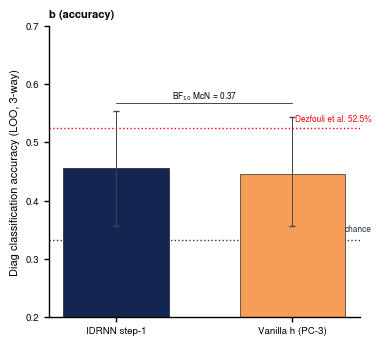

In [5]:
# Re-use the panel-b ensemble P matrices (same data flow, accuracy framing).
z_idr_30 = np.load(os.path.join(BASE_DIR, 'canonical/idrnn/all_30_step1_z.npy'))
h_van_30 = np.load('final_plots/dezfouli_z2_full/canonical/vanilla/all_30_h_avg.npy')
df_pp = pd.read_csv(os.path.join(BASE_DIR, 'per_participant_nll.csv'))
diag = df_pp['diag'].astype(str).values
le = LabelEncoder(); le.classes_ = np.array(DIAG_ORDER); y = le.transform(diag)
z_dim_idr = int(z_idr_30.shape[2])

P_i = ensemble_loo_lr(z_idr_30, z_dim_idr, y)
P_v = ensemble_loo_lr(h_van_30, z_dim_idr, y)
correct_i = (P_i.argmax(1) == y).astype(int)
correct_v = (P_v.argmax(1) == y).astype(int)
acc_i = float(correct_i.mean()); acc_v = float(correct_v.mean())

def bootstrap_acc(P, y, n_boot=2000, seed=21):
    rng = np.random.default_rng(seed); n = len(y); boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n); boots[i] = accuracy_score(y[idx], P[idx].argmax(1))
    return np.nanpercentile(boots, [2.5, 97.5])
lo_i, hi_i = bootstrap_acc(P_i, y, seed=31)
lo_v, hi_v = bootstrap_acc(P_v, y, seed=32)

bf_mcn, n_AB, n_BA = mcnemar_bf10(correct_i, correct_v)
bf_paired = paired_bf(correct_i, correct_v)
n_concordant_right = int(((correct_i==1)&(correct_v==1)).sum())
n_concordant_wrong = int(((correct_i==0)&(correct_v==0)).sum())

print(f'Strict dim match + per-fold PCA (both archs {z_dim_idr}-D inside LOO; 30-seed ensemble).')
print(f'IDRNN step-1: acc={acc_i*100:.1f}%  CI [{lo_i*100:.1f}%, {hi_i*100:.1f}%]   correct: {int(correct_i.sum())}/{len(y)}')
print(f'Vanilla h_pc: acc={acc_v*100:.1f}%  CI [{lo_v*100:.1f}%, {hi_v*100:.1f}%]   correct: {int(correct_v.sum())}/{len(y)}')
print(f'Both right: {n_concordant_right}  Both wrong: {n_concordant_wrong}  '
      f'IDRNN-only right (n_AB): {n_AB}  Vanilla-only right (n_BA): {n_BA}')
print(f'Bayesian McNemar BF₁₀ (IDRNN ≠ Vanilla acc): {fmt_bf(bf_mcn)}')
print(f'Paired-t BF₁₀ on per-subject correctness:    {fmt_bf(bf_paired)}')
print(f'Dezfouli (2019) supervised RNN benchmark:    {DEZFOULI_PAPER_ACCURACY*100:.1f}%   (chance: {100/3:.1f}%)')

fig, ax = plt.subplots(figsize=(SINGLE_COL_IN*1.1, SINGLE_COL_IN))
xs = np.arange(2); w = 0.6
ax.bar(xs, [acc_i, acc_v], w,
       color=[COL_IDRNN, COL_VANILLA],
       edgecolor='black', linewidth=0.4, zorder=2)
ax.errorbar(xs, [acc_i, acc_v],
            yerr=[[acc_i-lo_i, acc_v-lo_v], [hi_i-acc_i, hi_v-acc_v]],
            fmt='none', ecolor='#444444', elinewidth=0.7, capsize=2.5, zorder=3)
ax.axhline(1/3, ls=':', color=COL_TRUE, lw=1.0, zorder=1)
ax.text(1.45, 1/3+0.01, 'chance', ha='right', va='bottom', fontsize=6, color=COL_TRUE)
ax.axhline(DEZFOULI_PAPER_ACCURACY, ls=':', color='red', lw=1.0, zorder=1)
ax.text(1.45, DEZFOULI_PAPER_ACCURACY+0.008, 'Dezfouli et al. 52.5%',
        ha='right', va='bottom', fontsize=6, color='red')

ymax = max(hi_i, hi_v); h_step = 0.02
bracket(ax, 0, 1, ymax + 0.4*h_step, h_step*0.3, f'BF$_{{10}}$ McN = {fmt_bf(bf_mcn)}')
ax.set_xticks(xs); ax.set_xticklabels(['IDRNN step-1', f'Vanilla h (PC-{z_dim_idr})'])
ax.set_ylabel('Diag classification accuracy (LOO, 3-way)')
ax.set_ylim(0.2, 0.7)
ax.set_title('b (accuracy)', loc='left', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'panel_b_accuracy.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'panel_b_accuracy.pdf'),            bbox_inches='tight')
plt.show()


## Panel b (nonlinear, hard-label) — RBF-SVM accuracy + Bayesian McNemar

Hard-label version of the nonlinear decoding. The decision rule is `argmax(predict_proba)` (the same accuracy convention as the panel-b accuracy figure), and the models are compared with the **Bayesian McNemar test** (`mcnemar_bf10`) — paired, on per-subject *correctness* only, with no probabilistic likelihood term.

Bars (LOO 3-way accuracy of an RBF-SVM, per-fold `StandardScaler`+PCA, leak-free):

1. **IDRNN** — RBF on the IDRNN z-latent. At the z=1 headline the latent is 1-D, so the "full" and "1-PC" decoders coincide → a single bar.
2. **Vanilla (full)** — RBF on the full 15-D Vanilla `h`.
3. **Vanilla (PC-1)** — RBF on Vanilla `h` reduced to 1 PC (dimension-matched to IDRNN).

Brackets are McNemar BF₁₀ vs IDRNN (>3 → accuracies differ, the sign of n_AB−n_BA says which wins; <1/3 → equivalent). Chance = 1/3; red line = Dezfouli et al. (2019) supervised RNN accuracy (52.5%).

**Caveat:** the IDRNN edge here is a decision-threshold effect under Platt-calibrated `argmax`. The SVM's probability-free `clf.predict()` and its `decision_function` AUC do **not** reproduce it (see the chat diagnostic) — so read this as "the IDRNN 1-D latent supports a favourable decision threshold," not "the RBF separates the classes better."


IDRNN=28.7% (29/101)   Vanilla-full=37.6% (38/101)   Vanilla-PC1=33.7% (34/101)
McNemar BF10: IDRNN vs Vanilla-full = 0.89   IDRNN vs Vanilla-PC1 = 0.37


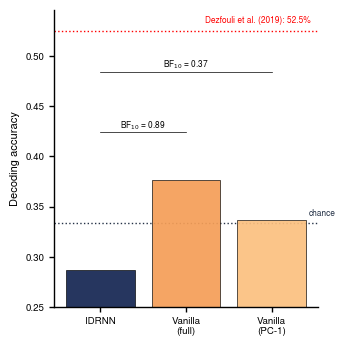

In [6]:
# ── Panel b (nonlinear, hard-label) — RBF-SVM accuracy + Bayesian McNemar ──
# Decision rule = argmax(predict_proba) (the figure's accuracy convention).
# Bars = LOO 3-way accuracy of an RBF-SVM (per-fold StandardScaler + PCA,
# leak-free; helpers in panelb_svm_decoding.py). Brackets = Bayesian McNemar
# BF10 vs IDRNN (mcnemar_bf10 — paired, hard-label, no probabilistic term).
# No per-bar error bars: a bar's bootstrap/binomial CI only describes its
# absolute precision vs chance, whereas the IDRNN-vs-Vanilla question is the
# (paired) McNemar BF — and CI overlap is not a valid paired test.
# z=1 headline: the IDRNN z-latent is 1-D, so its 'full' and '1-PC' RBF
# decoders coincide -> a single IDRNN bar.
from panelb_svm_decoding import diag_decode_loo_svm

z_idr = np.load(os.path.join(BASE_DIR, 'canonical/idrnn/latents_train_step1.npy'))
h_van = np.load('final_plots/dezfouli_z2_full/canonical/vanilla/latents_train.npy')
df_pp = pd.read_csv(os.path.join(BASE_DIR, 'per_participant_nll.csv'))
le = LabelEncoder(); le.classes_ = np.array(DIAG_ORDER)
y = le.transform(df_pp['diag'].astype(str).values)
z_dim_idr = int(z_idr.shape[1]); n = len(y)
COL_VAN_PC = nature_colors['Orange'][1]   # lighter orange for dim-matched Vanilla

def _corr(X, k):
    _, _, _, P = diag_decode_loo_svm(X, k, y)
    return (P.argmax(1) == y).astype(int)

bars = [('IDRNN',           COL_IDRNN,   _corr(z_idr, None)),       # z=1: full == 1-PC
        ('Vanilla\n(full)', COL_VANILLA, _corr(h_van, None)),
        ('Vanilla\n(PC-1)', COL_VAN_PC,  _corr(h_van, z_dim_idr))]
accs = [c.mean() for _, _, c in bars]
bf_full, *_ = mcnemar_bf10(bars[0][2], bars[1][2])
bf_pc,   *_ = mcnemar_bf10(bars[0][2], bars[2][2])

print(f'IDRNN={accs[0]*100:.1f}% ({bars[0][2].sum()}/{n})   '
      f'Vanilla-full={accs[1]*100:.1f}% ({bars[1][2].sum()}/{n})   '
      f'Vanilla-PC1={accs[2]*100:.1f}% ({bars[2][2].sum()}/{n})')
print(f'McNemar BF10: IDRNN vs Vanilla-full = {fmt_bf(bf_full)}   IDRNN vs Vanilla-PC1 = {fmt_bf(bf_pc)}')

fig, ax = plt.subplots(figsize=(SINGLE_COL_IN, SINGLE_COL_IN))
xs = np.arange(3)
ax.bar(xs, accs, color=[c for _, c, _ in bars], alpha=0.92, edgecolor='black', linewidth=0.5, zorder=2)
ax.axhline(1/3, ls=':', color=COL_TRUE, lw=1.0, zorder=1)
ax.text(2.75, 1/3 + 0.006, 'chance', ha='right', va='bottom', fontsize=6, color=COL_TRUE)
ax.axhline(DEZFOULI_PAPER_ACCURACY, ls=':', color='red', lw=1.0, zorder=1)
ax.text(2.46, DEZFOULI_PAPER_ACCURACY + 0.006, 'Dezfouli et al. (2019): 52.5%',
        ha='right', va='bottom', fontsize=6, color='red')
ytop = max(accs)
b1, b2 = ytop + 0.04, ytop + 0.10
bracket(ax, 0, 1, b1, 0.008, f'BF$_{{10}}$ = {fmt_bf(bf_full)}')
bracket(ax, 0, 2, b2, 0.008, f'BF$_{{10}}$ = {fmt_bf(bf_pc)}')
ax.set_xticks(xs); ax.set_xticklabels([l for l, _, _ in bars])
ax.set_ylabel('Decoding accuracy')
ax.set_ylim(0.25, b2 + 0.07)
#ax.set_title('b (nonlinear)', loc='left', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'panel_b_svm_mcnemar.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'panel_b_svm_mcnemar.pdf'), bbox_inches='tight')
plt.show()



## Panel b (nonlinear, z-scan) — RBF accuracy across IDRNN z-dim

The same RBF-SVM hard-label decoding (`argmax(predict_proba)`), repeated for each hypothesis-z anchor (z ∈ {1, 2, 3}), always against **dimension-matched** Vanilla — the 15-D `h` reduced to z PCs. Each group: IDRNN z-latent (z-D) vs Vanilla (z-PC); bracket = Bayesian McNemar BF₁₀ (IDRNN vs dim-matched Vanilla). Labels are read per-z from each anchor's own `per_participant_nll.csv`. Chance = 1/3.

This isolates whether the z=1 IDRNN accuracy edge survives at higher z — **it does not**: at z=2 and z=3 the IDRNN RBF accuracy falls *below* chance (28.7%) and dimension-matched Vanilla overtakes it, consistent with the z=1 latent being the effective individual-difference dimension.


z=1: IDRNN(1-D)=51.5% (52/101)   Vanilla(1-PC)=42.6% (43/101)   McNemar BF10=1.19


z=2: IDRNN(2-D)=28.7% (29/101)   Vanilla(2-PC)=38.6% (39/101)   McNemar BF10=1.59


z=3: IDRNN(3-D)=28.7% (29/101)   Vanilla(3-PC)=33.7% (34/101)   McNemar BF10=0.37


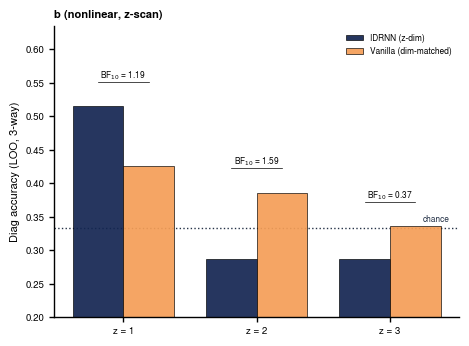

In [7]:
# ── Panel b (nonlinear, z-scan) — RBF accuracy across IDRNN z-dim ─────────
# Repeat the RBF-SVM hard-label decoding for each hypothesis-z anchor
# (z in {1,2,3}), always vs DIMENSION-MATCHED Vanilla (15-D h -> z PCs).
# Brackets = Bayesian McNemar BF10 (IDRNN vs dim-matched Vanilla). Diagnosis
# labels are read per-z from each anchor's own per_participant_nll.csv.
# No per-bar error bars: the paired comparison is carried by the McNemar BF.
from panelb_svm_decoding import diag_decode_loo_svm
h_van = np.load('final_plots/dezfouli_z2_full/canonical/vanilla/latents_train.npy')

ZS = [1, 2, 3]; rows = []
for Z in ZS:
    dfz = pd.read_csv(f'final_plots/dezfouli_z{Z}_full/per_participant_nll.csv')
    lez = LabelEncoder(); lez.classes_ = np.array(DIAG_ORDER)
    yz = lez.transform(dfz['diag'].astype(str).values)
    zi = np.load(f'final_plots/dezfouli_z{Z}_full/canonical/idrnn/latents_train_step1.npy')
    d = int(zi.shape[1])
    _, _, _, Pi = diag_decode_loo_svm(zi, None, yz)         # IDRNN, full z-D
    _, _, _, Pv = diag_decode_loo_svm(h_van, d, yz)         # Vanilla, dim-matched
    ci = (Pi.argmax(1) == yz).astype(int); cv = (Pv.argmax(1) == yz).astype(int)
    bf, *_ = mcnemar_bf10(ci, cv)
    rows.append(dict(Z=Z, d=d, acc_i=ci.mean(), acc_v=cv.mean(), bf=bf, n=len(yz)))
    print(f'z={Z}: IDRNN({d}-D)={ci.mean()*100:.1f}% ({ci.sum()}/{len(yz)})   '
          f'Vanilla({d}-PC)={cv.mean()*100:.1f}% ({cv.sum()}/{len(yz)})   McNemar BF10={fmt_bf(bf)}')

fig, ax = plt.subplots(figsize=(SINGLE_COL_IN * 1.35, SINGLE_COL_IN))
x = np.arange(len(ZS)); w = 0.38
ai = [r['acc_i'] for r in rows]; av = [r['acc_v'] for r in rows]
ax.bar(x - w/2, ai, w, color=COL_IDRNN, alpha=0.92, edgecolor='black', linewidth=0.5, label='IDRNN (z-dim)', zorder=2)
ax.bar(x + w/2, av, w, color=COL_VANILLA, alpha=0.92, edgecolor='black', linewidth=0.5, label='Vanilla (dim-matched)', zorder=2)
ax.axhline(1/3, ls=':', color=COL_TRUE, lw=1.0, zorder=1)
ax.text(len(ZS) - 0.55, 1/3 + 0.006, 'chance', ha='right', va='bottom', fontsize=6, color=COL_TRUE)
ytop = max(max(ai), max(av))
for i, r in enumerate(rows):
    top = max(ai[i], av[i]) + 0.03
    bracket(ax, x[i] - w/2, x[i] + w/2, top, 0.006, f'BF$_{{10}}$ = {fmt_bf(r["bf"])}')
ax.set_xticks(x); ax.set_xticklabels([f'z = {Z}' for Z in ZS])
ax.set_ylabel('Diag accuracy (LOO, 3-way)')
ax.set_ylim(0.20, ytop + 0.12)
ax.legend(loc='upper right', frameon=False, fontsize=6)
ax.set_title('b (nonlinear, z-scan)', loc='left', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'panel_b_svm_zscan.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'panel_b_svm_zscan.pdf'), bbox_inches='tight')
plt.show()


## Panel b′ — representational geometry: do diag groups separate in latent space?

Classification (panel b) asks *"can a linear LOO readout extract diagnosis at n=101?"* — and it has two bottlenecks that can hide a real model difference: argmax/AUC discard most of the geometry, and the LOO estimate is noisy at n=101 × 3 classes. This panel asks the question the IDRNN claim is actually about: **does the model organise individuals so diagnostic groups occupy distinct regions of latent space — more so than the vanilla RNN?** It is continuous, uses the full geometry, and is not capped by a downstream classifier's variance.

**The two confounds we must control.** Any distance/variance separation statistic is dominated by (a) **dimensionality** — 15-D vanilla h trivially spreads groups farther than 1-D IDRNN z — and (b) **scale** — vanilla's high-variance dims dominate Euclidean distance. The two archs differ on *both*. So, mirroring the "strict dim match" discipline of panel b, we **project both to the same k = z_dim PCs and whiten** (unit variance per dim). After this, any difference reflects group *structure*, not which model has more/larger latent dims. (In-sample PCA is fine here: it is label-agnostic, so the label-permutation null is unaffected.)

**Separation measure — PERMANOVA R²** (Anderson 2001). Fraction of variance in the (whitened, dim-matched) latent **distances** explained by diagnosis: `R² = SS_between / SS_total`, with pseudo-F `(SS_A/(a−1)) / (SS_W/(n−a))`. Distance-based, non-parametric. **For the z=1 headline this is exactly the one-way ANOVA η²** of a single latent coordinate (IDRNN z vs vanilla PC1); for z=2/3 it is the multivariate generalisation. R² is a fraction-of-variance effect size, comparable across models *once dim+scale are matched*.

**Per-model significance — label permutation** (5000×): permute diagnosis, recompute R²; `p = (1 + #{R²_perm ≥ R²_obs}) / (n_perm + 1)`. The mean null R² (≈ (a−1)/(n−1)) is drawn as the chance line — the honest reference, since E[R²|null] > 0 at finite n.

**The model comparison — paired bootstrap on ΔR².** Resample the 101 subjects with replacement, recompute *both* models' R² on the **same** resample (fixed whitened embeddings, resample rows — same convention as `bootstrap_auc_ci`), take Δ = R²_IDRNN − R²_vanilla → 95% CI and P(IDRNN > vanilla). This respects subject pairing and is the apples-to-apples "does IDRNN separate groups more" test — not comparing two independently-reported R²s. A **joint-label permutation** on ΔR² (same permuted labels applied to both spaces) gives the significance of the gap against the label-exchange null.

**Bayesian flavour (multivariate BIC, panel-e-consistent).** A single multivariate omnibus BF₁₀ via BIC, written through R²: `BF₁₀ = exp(( −n·log(1−R²) − (a−1)·k·log n ) / 2)`. At **k=1 this is exactly the panel-e `omnibus_bf_anova`**. The `(a−1)·k·log n` term is the BIC complexity penalty for the `a·k` group-mean coordinates — so at k>1 with modest R² the BF can favour the *null* even when the permutation p is significant. That is not a contradiction: the permutation tests *"is there any effect"*, the BIC-BF tests *"is the grouped model worth its extra parameters"*. (This replaces a naive product-of-per-dim-BF aggregation, which compounds whitened noise dims and is incoherent for k>1.)

> **Caveat (read before interpreting).** This measure was chosen because it is more sensitive and more on-claim than classification — **not** because it is the one that finally shows a gap. If a flexible supervised readout genuinely can't separate the two models, a geometric measure may also land null; that is a legitimate result and is reported as-is. No metric-shopping across separation statistics.


Strict dim-match + whiten: both archs -> 3 unit-variance dim(s).
Null E[R^2] ~ 0.020   ((a-1)/(n-1) = 0.020)
IDRNN  : R2=0.045  CI[0.024,0.115]  perm p=0.0290  pseudo-F=2.33  omnibus BF=0.00
Vanilla: R2=0.055  CI[0.029,0.134]  perm p=0.0098  pseudo-F=2.83  omnibus BF=0.00
dR2 (IDRNN-Vanilla) = -0.009  boot CI[-0.059,+0.041]  joint-perm p=0.4415  P(IDRNN>Vanilla)=0.351


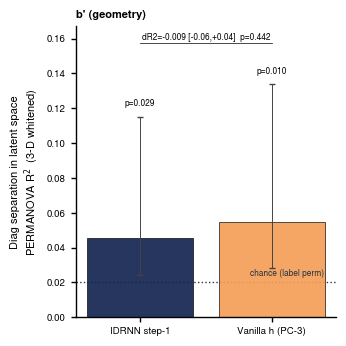

In [8]:
# ── Panel b' — diag-group separation in latent space (PERMANOVA R^2) ────────
# Strict dim-match + WHITEN both archs to k = z_dim unit-variance dims, then
# PERMANOVA R^2 (variance in latent distances explained by diagnosis), per-model
# label-permutation p, paired bootstrap dR^2, and a multivariate BIC omnibus BF.
z_idr = np.load(os.path.join(BASE_DIR, 'canonical/idrnn/latents_train_step1.npy'))
h_van = np.load('final_plots/dezfouli_z2_full/canonical/vanilla/latents_train.npy')
df_pp = pd.read_csv(os.path.join(BASE_DIR, 'per_participant_nll.csv'))
diag = df_pp['diag'].astype(str).values
le = LabelEncoder(); le.classes_ = np.array(DIAG_ORDER); y = le.transform(diag)
k = int(z_idr.shape[1])
a = len(np.unique(y))

def dim_match_whiten(X_raw, k):
    """Project to k dims (PCA if D>k, else identity) then z-score each dim to
    unit variance. Equalises dimensionality AND scale across architectures so a
    distance-based measure reflects group structure, not which model has the
    larger/more latent dims. PCA fit in-sample is fine: it is label-agnostic, so
    the label-permutation null is unaffected."""
    X = np.asarray(X_raw, float); D = X.shape[1]
    Z = PCA(n_components=k, whiten=True).fit_transform(X) if D > k else X.copy()
    return (Z - Z.mean(0)) / (Z.std(0) + 1e-12)

def sqdist(X):
    X = np.asarray(X, float)
    return ((X[:, None, :] - X[None, :, :]) ** 2).sum(-1)

def permanova_from_sq(sq, g):
    """R^2, pseudo-F from a squared-Euclidean distance matrix + labels
    (Anderson 2001). R^2 = SS_between / SS_total. For 1-D whitened input this
    equals the one-way ANOVA eta^2."""
    n = len(g); levels = np.unique(g); a = len(levels)
    SS_T = sq[np.triu_indices(n, 1)].sum() / n
    SS_W = 0.0
    for lev in levels:
        idx = np.where(g == lev)[0]; ng = len(idx)
        if ng > 1:
            SS_W += sq[np.ix_(idx, idx)][np.triu_indices(ng, 1)].sum() / ng
    SS_A = SS_T - SS_W
    R2 = SS_A / SS_T if SS_T > 0 else np.nan
    F = (SS_A / (a - 1)) / (SS_W / (n - a)) if (a > 1 and n > a and SS_W > 0) else np.nan
    return float(R2), float(F)

def omnibus_bf_from_r2(R2, n, a, k):
    """Multivariate Bayesian omnibus BF10 via BIC, expressed through PERMANOVA
    R^2: BF10 = exp(( -n*log(1-R2) - (a-1)*k*log(n) ) / 2). For k=1 this is
    exactly the panel-e 1-way ANOVA `omnibus_bf_anova`. The (a-1)*k*log(n) term
    is the BIC complexity penalty for the a*k group-mean coordinates, so at k>1
    with modest R^2 the BF can favour the null even when the permutation p is
    significant -- the two ask different questions (effect-worth-its-parameters
    vs. any-effect)."""
    if not (0 < R2 < 1): return float('nan')
    return float(np.exp((-n * np.log(1 - R2) - (a - 1) * k * np.log(n)) / 2))

# Dim-match + whiten both archs to k unit-variance dims
Z_idr = dim_match_whiten(z_idr, k)
Z_van = dim_match_whiten(h_van, k)
sq_idr = sqdist(Z_idr); sq_van = sqdist(Z_van)
R2_i, F_i = permanova_from_sq(sq_idr, y)
R2_v, F_v = permanova_from_sq(sq_van, y)
dR2_obs = R2_i - R2_v

# Per-model significance + dR^2 significance via JOINT label permutation
rng = np.random.default_rng(7); N_PERM = 5000
null_i = np.empty(N_PERM); null_v = np.empty(N_PERM); null_d = np.empty(N_PERM)
for b in range(N_PERM):
    yp = rng.permutation(y)
    ri, _ = permanova_from_sq(sq_idr, yp)   # sq fixed under label permutation -> reused
    rv, _ = permanova_from_sq(sq_van, yp)
    null_i[b] = ri; null_v[b] = rv; null_d[b] = ri - rv
p_i = (1 + np.sum(null_i >= R2_i - 1e-12)) / (N_PERM + 1)
p_v = (1 + np.sum(null_v >= R2_v - 1e-12)) / (N_PERM + 1)
p_d = (1 + np.sum(np.abs(null_d) >= abs(dR2_obs) - 1e-12)) / (N_PERM + 1)  # two-sided
chance_R2 = float(np.mean(np.concatenate([null_i, null_v])))               # E[R^2|null]

# Paired bootstrap of subjects (fixed embeddings, resample rows) -> CIs on R^2 & dR^2
rng = np.random.default_rng(13); N_BOOT = 2000; n = len(y)
boot_i = np.empty(N_BOOT); boot_v = np.empty(N_BOOT); boot_d = np.empty(N_BOOT)
for b in range(N_BOOT):
    idx = rng.integers(0, n, n)
    ri, _ = permanova_from_sq(sqdist(Z_idr[idx]), y[idx])
    rv, _ = permanova_from_sq(sqdist(Z_van[idx]), y[idx])
    boot_i[b] = ri; boot_v[b] = rv; boot_d[b] = ri - rv
lo_i, hi_i = np.percentile(boot_i, [2.5, 97.5])
lo_v, hi_v = np.percentile(boot_v, [2.5, 97.5])
lo_d, hi_d = np.percentile(boot_d, [2.5, 97.5])
p_boot_gt0 = float(np.mean(boot_d > 0))

# Multivariate BIC omnibus BF (k=1 -> exactly the panel-e single-coordinate BF)
bf_om_i = omnibus_bf_from_r2(R2_i, n, a, k)
bf_om_v = omnibus_bf_from_r2(R2_v, n, a, k)

print(f'Strict dim-match + whiten: both archs -> {k} unit-variance dim(s).')
print(f'Null E[R^2] ~ {chance_R2:.3f}   ((a-1)/(n-1) = {(a-1)/(n-1):.3f})')
print(f'IDRNN  : R2={R2_i:.3f}  CI[{lo_i:.3f},{hi_i:.3f}]  perm p={p_i:.4f}  pseudo-F={F_i:.2f}  omnibus BF={fmt_bf(bf_om_i)}')
print(f'Vanilla: R2={R2_v:.3f}  CI[{lo_v:.3f},{hi_v:.3f}]  perm p={p_v:.4f}  pseudo-F={F_v:.2f}  omnibus BF={fmt_bf(bf_om_v)}')
print(f'dR2 (IDRNN-Vanilla) = {dR2_obs:+.3f}  boot CI[{lo_d:+.3f},{hi_d:+.3f}]  '
      f'joint-perm p={p_d:.4f}  P(IDRNN>Vanilla)={p_boot_gt0:.3f}')

fig, ax = plt.subplots(figsize=(SINGLE_COL_IN, SINGLE_COL_IN))
xs = [0, 1]
ax.bar(xs, [R2_i, R2_v], color=[COL_IDRNN, COL_VANILLA], alpha=0.92,
       edgecolor='black', linewidth=0.5, zorder=2)
ax.errorbar(xs, [R2_i, R2_v],
            yerr=[[R2_i - lo_i, R2_v - lo_v], [hi_i - R2_i, hi_v - R2_v]],
            fmt='none', ecolor='#444444', elinewidth=0.7, capsize=2.5, zorder=3)
ax.axhline(chance_R2, ls=':', color=COL_TRUE, lw=1.0, zorder=1)
ax.text(1.4, chance_R2 + 0.003, 'chance (label perm)', ha='right', va='bottom', fontsize=6, color=COL_TRUE)
for xi, hiv, pv in zip(xs, [hi_i, hi_v], [p_i, p_v]):
    ax.text(xi, hiv + 0.005, (f'p={pv:.3f}' if pv >= 1e-3 else 'p<0.001'), ha='center', va='bottom', fontsize=6)
ymax = max(hi_i, hi_v); h_step = max(0.012, ymax * 0.07)
bracket(ax, 0, 1, ymax + 1.7 * h_step, h_step * 0.3,
        f'dR2={dR2_obs:+.3f} [{lo_d:+.2f},{hi_d:+.2f}]  p={p_d:.3f}')
ax.set_xticks(xs); ax.set_xticklabels(['IDRNN step-1', f'Vanilla h (PC-{k})'])
ax.set_ylabel(f'Diag separation in latent space\nPERMANOVA R$^2$  ({k}-D whitened)')
ax.set_ylim(0, ymax + 2.8 * h_step)
ax.set_title("b' (geometry)", loc='left', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'panel_b_geometry.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'panel_b_geometry.pdf'), bbox_inches='tight')
plt.show()


## Panel b'' - data-scaling: how many trials does diagnostic structure need?

Panels b / b' established that IDRNN and Vanilla **tie at full data**. This panel asks the sharper question behind the individual-difference claim: does IDRNN reach that structure with *less behaviour*? For each trial budget **T** we build a per-subject latent from the **first T valid trials** of the session (blocks concatenated in order) and score its diagnostic-group structure exactly as in panel b' (**PERMANOVA R**$^2$, dim-matched + whitened to k=z_dim) and panel b (**LOO macro-AUC**).

**Latents used (and why).**
- **IDRNN z (step-1, amortised)** - the per-subject `nn.Embedding` lookup (`latents_train_step1.npy`), the latent panels b/c use. Per `REPLICATION_DEZFOULI_THALMANN.md` Sec.2: step-1 trains the decoder against a *free* per-subject embedding, so it is the **maximally informative** per-subject code the architecture can hold at this z_dim - it isolates representational *capacity* from encoder *distillation*. It is **trial-independent** (not read from behaviour), so it is a flat reference band, not a curve.
- **IDRNN encoder (test-time)** - the step-2 encoder's per-trial mu (`return_per_timestep=True`): the latent the model *infers from behaviour at test time*. This is the apples-to-apples partner to Vanilla - both are read out online from the first T trials. (On Dezfouli z=1 the step-2 encoder is compressed but **not** collapsed: std 0.24 vs step-1's 0.40; the z=2 collapse noted in Sec.2 is why decoding panels use step-1.)
- **Vanilla h** - the GRU hidden state, also read out online.

**How the two online read-outs are accumulated (identical rule for both models).** With `block_structure=True` the GRU hidden state **resets every block**, so a single timestep never carries cross-block memory. From the per-trial latent sequence (Vanilla h or encoder mu) we form, at budget T:
- **mean** - running average of the per-trial latent over the first T valid trials (averages many within-block states, so it accumulates subject evidence *across* blocks);
- **last** - the latent at the T-th valid trial (reflects only its own block's recent history -> noisy, never accumulates).

Common support: every subject has >=398 valid trials, so all 101 contribute at every T. Bands = subject-bootstrap 95% CI. Chance: R$^2$ ~ (a-1)/(n-1) = 0.02, AUC = 0.5.

**Vanilla: dim-matched vs full h.** Vanilla h is 15-D; to compare *capacity-for-capacity* with the 1-D IDRNN z we dim-match it (PCA->k=z_dim + whiten), exactly as panels b/b'. We also plot **full 15-D** vanilla (no reduction) as a darker diamond series - on the **cross-validated AUC** panel this is the fair full-h read-out. Note the two metrics diverge for full h: PERMANOVA R$^2$ is *deflated* at 15-D (whitening gives the ~13 diagnosis-irrelevant dims equal weight, diluting the signal that lives in 1-2 dims), whereas the supervised LOO-AUC can ignore the noise dims - so judge full-h capacity by AUC, not R$^2$.

**Read-out.** The IDRNN **encoder** reaches its diagnostic-structure plateau within ~15-20 trials, while **Vanilla (mean)** needs ~150+ trials to climb to a comparable level; **Vanilla (last)** never accumulates (block reset). Both eventually meet the amortised step-1 reference - the point is *how fast*. Data source: `final_plots/dezfouli_z{Z_DIM}_full/publication_figure/datascaling.csv`, written by `analyze_dezfouli_datascaling.py`.


In [9]:
if not os.path.exists(os.path.join(OUT_DIR, 'datascaling.csv')):
    print(f'[skip] {os.path.join(OUT_DIR, "datascaling.csv")} not found — '
          f'rerun analyze_dezfouli_datascaling.py --z_dim {Z_DIM}')
else:
    # ── Panel b'' — data-scaling: diagnostic structure vs number of trials seen ──
    # Curves are precomputed by analyze_dezfouli_datascaling.py (it needs the torch
    # forward pass); this cell only PLOTS, in the publication aesthetic. Re-run
    #   python analyze_dezfouli_datascaling.py --z_dim {Z_DIM}
    # to regenerate datascaling.csv for another z anchor.
    ds   = pd.read_csv(os.path.join(OUT_DIR, 'datascaling.csv'))
    grid = ds[ds['T'] >= 0]
    flat = ds[ds['model'] == 'idrnn_step1_amortised'].iloc[0]   # trial-independent reference
    chance = {'r2': 2 / (101 - 1), 'auc': 0.5}

    CURVES = [
        ('vanilla_mean',      COL_VANILLA,    '-',  'o', 'Vanilla h (k=1, matched) - mean'),
        ('vanilla_mean_full', COL_VAN_H_LAST, '-',  'D', 'Vanilla h (full 15-D) - mean'),
        ('vanilla_last',      COL_VAN_H,      '--', 's', 'Vanilla h (k=1) - last'),
        ('idrnn_step2_mean',  COL_IDRNN,      '-',  'o', 'IDRNN encoder (test-time) - mean'),
        ('idrnn_step2_last',  COL_IDRNN,      '--', 's', 'IDRNN encoder (test-time) - last'),
    ]
    PANELS = [('r2',  'Diag separation  -  PERMANOVA R$^2$'),
              ('auc', 'Diag decoding  -  LOO macro-AUC')]

    fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL_IN, SINGLE_COL_IN))
    for ax, (metric, ylab) in zip(axes, PANELS):
        for tag, col, ls, mk, lab in CURVES:
            s = grid[grid['model'] == tag].sort_values('T')
            ax.plot(s['T'], s[metric], ls=ls, marker=mk, ms=3, lw=1.3, color=col, label=lab, zorder=3)
            ax.fill_between(s['T'], s[f'{metric}_lo'], s[f'{metric}_hi'], color=col, alpha=0.12, lw=0, zorder=1)
        # IDRNN step-1 lookup (amortised, trial-independent) reference band + line
        ax.axhspan(flat[f'{metric}_lo'], flat[f'{metric}_hi'], color=COL_RNN_CP, alpha=0.12, zorder=1)
        ax.axhline(flat[metric], color=COL_RNN_CP, lw=1.6, zorder=2, label='IDRNN z (step-1, amortised)')
        ax.axhline(chance[metric], ls=':', color=COL_TRUE, lw=1.0, zorder=1)
        ax.text(grid['T'].min(), chance[metric], ' chance', ha='left', va='bottom', fontsize=6, color=COL_TRUE)
        ax.set_xlabel('Number of trials seen (T)'); ax.set_ylabel(ylab)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    axes[0].set_ylim(0, None)
    axes[0].legend(loc='upper left', frameon=False, fontsize=5.6, handlelength=1.8)
    axes[0].set_title("b''", loc='left', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'panel_datascaling_pub.png'), dpi=600, bbox_inches='tight')
    plt.savefig(os.path.join(OUT_DIR, 'panel_datascaling_pub.pdf'),            bbox_inches='tight')
    plt.show()

    Tmin = int(grid['T'].min())
    def _at(m, T):
        r = grid[(grid.model == m) & (grid['T'] == T)].iloc[0]; return r['r2'], r['auc']
    print(f"IDRNN step-1 (amortised) reference : R2={flat['r2']:.3f}  AUC={flat['auc']:.3f}")
    print(f"T={Tmin:>3}: IDRNN-enc  R2={_at('idrnn_step2_mean',Tmin)[0]:.3f} AUC={_at('idrnn_step2_mean',Tmin)[1]:.3f}   "
          f"Vanilla  R2={_at('vanilla_mean',Tmin)[0]:.3f} AUC={_at('vanilla_mean',Tmin)[1]:.3f}")


[skip] final_plots/dezfouli_z3_full/publication_figure/datascaling.csv not found — rerun analyze_dezfouli_datascaling.py --z_dim 3


### Panel b'' (clean) - selected series, no variance bands

Same data-scaling data as above, but only the four series of interest and **no CI bands**, so the trajectories are legible: IDRNN z (step-1, amortised, flat) vs Vanilla h read out three ways - **k=1 mean** (dim-matched, the fair capacity-matched comparison), **full 15-D mean** (vanilla's full decoding capacity), and **k=1 last** (single-timestep, never accumulates due to per-block reset).

In [10]:
if not os.path.exists(os.path.join(OUT_DIR, 'datascaling.csv')):
    print(f'[skip] {os.path.join(OUT_DIR, "datascaling.csv")} not found — '
          f'rerun analyze_dezfouli_datascaling.py --z_dim {Z_DIM}')
else:
    # ── Panel b'' (clean) — selected series, lines only (no CI bands) ────────────
    ds   = pd.read_csv(os.path.join(OUT_DIR, 'datascaling.csv'))
    grid = ds[ds['T'] >= 0]
    flat = ds[ds['model'] == 'idrnn_step1_amortised'].iloc[0]
    chance = {'r2': 2 / (101 - 1), 'auc': 0.5}

    CURVES = [
        ('vanilla_mean',      COL_VANILLA,    '-',  'o', 'Vanilla h (k=1) - mean'),
        ('vanilla_mean_full', COL_VAN_H_LAST, '-',  'D', 'Vanilla h (full 15-D) - mean'),
        ('vanilla_last',      COL_VAN_H,      '--', 's', 'Vanilla h (k=1) - last'),
    ]
    PANELS = [('r2',  'Diag separation  -  PERMANOVA R$^2$'),
              ('auc', 'Diag decoding  -  LOO macro-AUC')]

    fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL_IN, SINGLE_COL_IN))
    for ax, (metric, ylab) in zip(axes, PANELS):
        for tag, col, ls, mk, lab in CURVES:
            s = grid[grid['model'] == tag].sort_values('T')
            ax.plot(s['T'], s[metric], ls=ls, marker=mk, ms=3.2, lw=1.6, color=col, label=lab, zorder=3)
        ax.axhline(flat[metric], color=COL_IDRNN, lw=1.8, zorder=2, label='IDRNN z (step-1, amortised)')
        ax.axhline(chance[metric], ls=':', color=COL_TRUE, lw=1.0, zorder=1)
        ax.text(grid['T'].min(), chance[metric], ' chance', ha='left', va='bottom', fontsize=6, color=COL_TRUE)
        ax.set_xlabel('Number of trials seen (T)'); ax.set_ylabel(ylab)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    axes[0].set_ylim(0, None)
    axes[0].legend(loc='upper left', frameon=False, fontsize=6, handlelength=1.8)
    axes[0].set_title("b'' (clean)", loc='left', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'panel_datascaling_clean.png'), dpi=600, bbox_inches='tight')
    plt.savefig(os.path.join(OUT_DIR, 'panel_datascaling_clean.pdf'),            bbox_inches='tight')
    plt.show()


[skip] final_plots/dezfouli_z3_full/publication_figure/datascaling.csv not found — rerun analyze_dezfouli_datascaling.py --z_dim 3


## Panel c — PC1(step-1 IDRNN z) per diag group

z=2 → project to PC1 for visualisation. Strip plot per group + jittered subjects + group means + pairwise BF brackets (Healthy–Depression, Healthy–Bipolar, Depression–Bipolar).

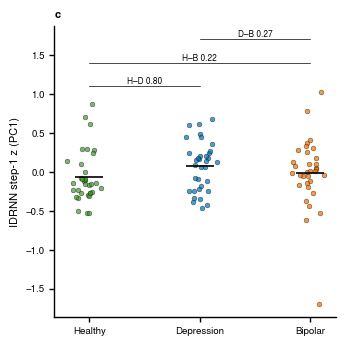

In [11]:
z_idr = np.load(os.path.join(BASE_DIR, 'canonical/idrnn/latents_train_step1.npy'))
df_pp = pd.read_csv(os.path.join(BASE_DIR, 'per_participant_nll.csv'))
diag = df_pp['diag'].astype(str).values

z1 = (PCA(n_components=1).fit_transform(z_idr).reshape(-1)
      if z_idr.shape[1] > 1 else z_idr.reshape(-1))

fig, ax = plt.subplots(figsize=(SINGLE_COL_IN, SINGLE_COL_IN))
rng = np.random.default_rng(7)
for i, g in enumerate(DIAG_ORDER):
    m = (diag == g)
    if m.sum() == 0: continue
    ax.scatter(i + rng.normal(0, 0.08, m.sum()), z1[m], s=12,
               c=[COL_DIAG[g]], alpha=0.7, edgecolors='black', linewidth=0.3)
    ax.scatter([i], [z1[m].mean()], marker='_', s=400, c='black', linewidths=1.2)

g_h = z1[diag=='Healthy']; g_d = z1[diag=='Depression']; g_b = z1[diag=='Bipolar']
bf_hd = two_group_bf(g_h, g_d)
bf_hb = two_group_bf(g_h, g_b)
bf_db = two_group_bf(g_d, g_b)
ymax = z1.max(); h_step = 0.085 * (z1.max() - z1.min() + 1e-3)
bracket(ax, 0, 1, ymax,             h_step*0.3, f'H–D {fmt_bf(bf_hd)}')
bracket(ax, 0, 2, ymax + 1.3*h_step, h_step*0.3, f'H–B {fmt_bf(bf_hb)}')
bracket(ax, 1, 2, ymax + 2.6*h_step, h_step*0.3, f'D–B {fmt_bf(bf_db)}')
ax.set_xticks(range(len(DIAG_ORDER))); ax.set_xticklabels(DIAG_ORDER)
ax.set_ylabel('IDRNN step-1 z (PC1)' if z_idr.shape[1] > 1 else 'IDRNN step-1 z')
ax.set_title('c', loc='left', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'panel_c.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'panel_c.pdf'),            bbox_inches='tight')
plt.show()

## Panel e — three-regression simulation (R1 / R0 / R2 / R3 → diag, perseverance)

We compute **one perseverance value per subject** under four protocols, then ask how well each separates diagnostic groups:

| metric | what it marginalises | what it measures |
|---|---|---|
| **R1** | nothing — observation | The subject's observed perseverance P(c_t == c_{t-1}) within blocks, computed directly from the raw `for_plos.csv` choice sequence (101 subjects × 12 blocks). |
| **R0 IDRNN** | nothing — single rollout | One rollout under the **subject's exact** (good_arm, good_prob) per block (deduced from `best_action`), feeding the canonical IDRNN step-1 z + pre-step-2.5 decoder. Single RNG draw → noisy realisation of what the model predicts the subject would do once. |
| **R2 IDRNN** | RNG | Same exact-env setup as R0 but average K=20 rollouts → one value per subject. Marginalises **RNG only**. |
| **R3 IDRNN** | RNG **and** env | M=20 fresh envs from `simulate_dezfouli_bandit` (canonical Dezfouli generative distribution), one rollout per env, average → one value per subject. Marginalises **RNG and env**. |

The R0 → R2 → R3 progression is the methodological ladder: how much of the diag-relevant subject signal survives marginalisation over progressively more nuisance variation?

### Tests on each bar

**Bar height: LOO 1-feature logistic-regression macro-AUC.**
- 1-vs-rest LR (`class_weight='balanced'`) fit on N−1 subjects using only this single metric value, predict held-out subject's diag probabilities, average ROC-AUC across the 3 classes. Chance = 0.5. Per-class AUCs shown as overlaid markers.

**Bootstrap CIs (error bars).**
- 2000 bootstrap resamples of subjects with replacement; for each, recompute macro AUC from the saved LOO predictions. Plot 2.5 / 97.5 percentile as asymmetric error bars (mirrors the bootstrap-r CI convention used in `synthetic_publication_panels.ipynb`).

**Pairwise Bayes factors (above each bar).** All hypothesis tests are Bayesian.
- For each binary contrast (Healthy–Depression, Healthy–Bipolar, Depression–Bipolar):
  - Welch's t-statistic on the two-group means of the metric.
  - BF₁₀ via `pingouin.bayesfactor_ttest(t, n, paired=False)` with the **JZS default prior (Cauchy scale r=√2/2)**.
  - BF₁₀ > 3 = moderate evidence for difference; > 10 = strong; < 1/3 = evidence for the null.

Data source: `final_plots/dezfouli_z{Z_DIM}_full/three_regressions_dezfouli.npz`

R1_perseverance           sum BF=  39.90   sum log10 BF=+1.76   omnibus BF=   12.06
R0_idrnn_persev           sum BF=  35.64   sum log10 BF=+1.67   omnibus BF=    9.76
R2_idrnn_persev           sum BF=  44.10   sum log10 BF=+1.92   omnibus BF=   16.14
R3_idrnn_persev           sum BF=  55.31   sum log10 BF=+2.09   omnibus BF=   20.80


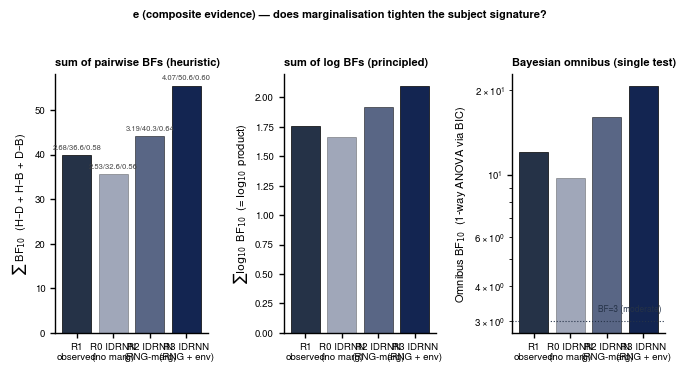

In [12]:
tr = np.load(os.path.join(BASE_DIR, 'three_regressions_dezfouli.npz'), allow_pickle=True)
diag = tr['diag']
BARS = [
    ('R1\nobserved',        'R1_perseverance',   COL_TRUE,    1.00),
    ('R0 IDRNN\n(no marg)',       'R0_idrnn_persev',   COL_IDRNN,   0.40),
    ('R2 IDRNN\n(RNG-marg)',      'R2_idrnn_persev',   COL_IDRNN,   0.70),
    ('R3 IDRNN\n(RNG + env)',     'R3_idrnn_persev',   COL_IDRNN,   1.00),
]

def omnibus_bf_anova(x, group_idx):
    """Bayesian one-way ANOVA BF10 via BIC approximation.
    BF_10 ≈ exp((BIC_null − BIC_alt) / 2). BIC = n*log(SSE/n) + k*log(n).
    null: 1 parameter (grand mean). alt: K parameters (per-group means)."""
    x = np.asarray(x, float); g = np.asarray(group_idx, int)
    m = np.isfinite(x); x = x[m]; g = g[m]
    n = len(x); K = len(np.unique(g))
    sse_null = ((x - x.mean())**2).sum()
    sse_alt  = sum(((x[g==k] - x[g==k].mean())**2).sum() for k in np.unique(g))
    # BIC: number of free params (k) for each model: null has 2 (mean + var),
    # alt has K+1 (K means + shared variance). Use this convention.
    bic_null = n*np.log(sse_null/n) + 2*np.log(n)
    bic_alt  = n*np.log(sse_alt /n) + (K+1)*np.log(n)
    return float(np.exp((bic_null - bic_alt) / 2))

rows = []
for label, key, color, alpha in BARS:
    x = tr[key].astype(float)
    bf_hd = two_group_bf(x[diag=='Healthy'],    x[diag=='Depression'])
    bf_hb = two_group_bf(x[diag=='Healthy'],    x[diag=='Bipolar'])
    bf_db = two_group_bf(x[diag=='Depression'], x[diag=='Bipolar'])
    g_idx = np.where(diag=='Healthy', 0, np.where(diag=='Depression', 1, 2))
    bf_om = omnibus_bf_anova(x, g_idx)
    sum_bf = bf_hd + bf_hb + bf_db
    sum_log_bf = (np.log10(bf_hd) + np.log10(bf_hb) + np.log10(bf_db))
    rows.append(dict(label=label, color=color, alpha=alpha,
                     bf_hd=bf_hd, bf_hb=bf_hb, bf_db=bf_db,
                     sum_bf=sum_bf, sum_log_bf=sum_log_bf, bf_omnibus=bf_om))
    print(f"{key:<24}  sum BF={sum_bf:7.2f}   sum log10 BF={sum_log_bf:+5.2f}   "
          f"omnibus BF={bf_om:8.2f}")

fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL_IN*0.95, SINGLE_COL_IN))
xs = np.arange(len(rows))
labels = [r['label'] for r in rows]
colors = [r['color'] for r in rows]; alphas = [r['alpha'] for r in rows]

ax = axes[0]
vals = [r['sum_bf'] for r in rows]
for xi, v, c, a in zip(xs, vals, colors, alphas):
    ax.bar(xi, v, color=c, alpha=a, edgecolor='black', linewidth=0.5)
ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel(r'$\sum$ BF$_{10}$  (H–D + H–B + D–B)')
ax.set_title('sum of pairwise BFs (heuristic)', loc='left', fontweight='bold', fontsize=8)
for xi, r in zip(xs, rows):
    ax.text(xi, r['sum_bf']*1.02,
            f'{fmt_bf(r["bf_hd"])}/{fmt_bf(r["bf_hb"])}/{fmt_bf(r["bf_db"])}',
            ha='center', va='bottom', fontsize=5.5, color='#444')

ax = axes[1]
vals = [r['sum_log_bf'] for r in rows]
for xi, v, c, a in zip(xs, vals, colors, alphas):
    ax.bar(xi, v, color=c, alpha=a, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='grey', lw=0.6)
ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel(r'$\sum \log_{10}$ BF$_{10}$  (= $\log_{10}$ product)')
ax.set_title('sum of log BFs (principled)', loc='left', fontweight='bold', fontsize=8)

ax = axes[2]
vals = [r['bf_omnibus'] for r in rows]
for xi, v, c, a in zip(xs, vals, colors, alphas):
    ax.bar(xi, v, color=c, alpha=a, edgecolor='black', linewidth=0.5)
ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel('Omnibus BF$_{10}$  (1-way ANOVA via BIC)')
ax.set_title('Bayesian omnibus (single test)', loc='left', fontweight='bold', fontsize=8)
ax.set_yscale('log')
ax.axhline(3, color=COL_TRUE, ls=':', lw=0.8)
ax.text(len(xs)-0.5, 3.2, 'BF=3 (moderate)', ha='right', va='bottom', fontsize=6, color=COL_TRUE)

plt.suptitle('e (composite evidence) — does marginalisation tighten the subject signature?', fontsize=8, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'panel_e_composite_bf.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'panel_e_composite_bf.pdf'),            bbox_inches='tight')
plt.show()

## Panel e (per-subject view) — perseverance distributions by diag, four panels

Strip plot of the per-subject perseverance value under each regression (R1, R0, R2, R3), one subplot per regression, colored by diagnosis. This is the qualitative complement to the BF composite: as marginalisation progresses you should see the within-group spreads contract (rollouts denoise per-subject noise) and the between-group separation become visually cleaner — exactly the pattern that drives the BF gains even when the macro-AUC ranking ordering stays essentially the same.

R1_perseverance           AUC=0.607  CI [0.526, 0.685]  acc=48.5%   BF₁₀  H-D=  2.68  H-B= 36.64  D-B=  0.58


R0_idrnn_persev           AUC=0.592  CI [0.512, 0.668]  acc=47.5%   BF₁₀  H-D=  2.53  H-B= 32.55  D-B=  0.56


R2_idrnn_persev           AUC=0.596  CI [0.515, 0.677]  acc=42.6%   BF₁₀  H-D=  3.19  H-B= 40.27  D-B=  0.64


R3_idrnn_persev           AUC=0.595  CI [0.519, 0.674]  acc=45.5%   BF₁₀  H-D=  4.07  H-B= 50.64  D-B=  0.60


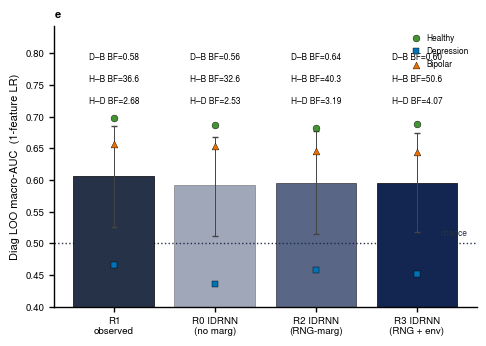

In [13]:
tr = np.load(os.path.join(BASE_DIR, 'three_regressions_dezfouli.npz'), allow_pickle=True)
diag = tr['diag']
le = LabelEncoder(); le.classes_ = np.array(DIAG_ORDER); y = le.transform(diag)

# Four bars: R1 (observed), R0 (single-rollout exact env), R2 (RNG-marg exact),
# R3 (RNG + env-marg). Conceptual ladder of progressively more marginalisation.
BARS = [
    ('R1\nobserved',           'R1_perseverance',   COL_TRUE,    1.00),
    ('R0 IDRNN\n(no marg)',          'R0_idrnn_persev',   COL_IDRNN,   0.40),
    ('R2 IDRNN\n(RNG-marg)',         'R2_idrnn_persev',   COL_IDRNN,   0.70),
    ('R3 IDRNN\n(RNG + env)',        'R3_idrnn_persev',   COL_IDRNN,   1.00),
]

stats_rows = []
for label, key, color, alpha in BARS:
    x = tr[key].astype(float)
    auc, acc, aucs, P = loo_auc_1feat(x, y)
    lo, hi, _ = bootstrap_auc_ci(P, y, n_boot=2000, seed=hash(key) & 0xffff)
    bf_hd = two_group_bf(x[diag=='Healthy'],    x[diag=='Depression'])
    bf_hb = two_group_bf(x[diag=='Healthy'],    x[diag=='Bipolar'])
    bf_db = two_group_bf(x[diag=='Depression'], x[diag=='Bipolar'])
    stats_rows.append(dict(label=label, key=key, color=color, alpha=alpha,
                           auc=auc, acc=acc, aucs=aucs, lo=lo, hi=hi,
                           bf_hd=bf_hd, bf_hb=bf_hb, bf_db=bf_db, x=x))
    print(f"{key:<24}  AUC={auc:.3f}  CI [{lo:.3f}, {hi:.3f}]  acc={acc*100:.1f}%   "
          f"BF₁₀  H-D={bf_hd:6.2f}  H-B={bf_hb:6.2f}  D-B={bf_db:6.2f}")

fig, ax = plt.subplots(figsize=(SINGLE_COL_IN*1.4, SINGLE_COL_IN))
xs = np.arange(len(stats_rows))
for xi, r in zip(xs, stats_rows):
    ax.bar(xi, r['auc'], color=r['color'], alpha=r['alpha'],
           edgecolor='black', linewidth=0.5, zorder=2)
# Bootstrap CI error bars
yerr_lo = [r['auc'] - r['lo'] for r in stats_rows]
yerr_hi = [r['hi'] - r['auc'] for r in stats_rows]
ax.errorbar(xs, [r['auc'] for r in stats_rows], yerr=[yerr_lo, yerr_hi],
            fmt='none', ecolor='#444444', elinewidth=0.7, capsize=2.5, zorder=3)
# Per-class AUC markers
markers = ['o', 's', '^']
for xi, r in zip(xs, stats_rows):
    for j, g in enumerate(DIAG_ORDER):
        ax.scatter([xi], [r['aucs'][j]], marker=markers[j], s=24, c=COL_DIAG[g],
                   edgecolor='black', linewidth=0.3, zorder=5)
ax.axhline(0.5, ls=':', color=COL_TRUE, lw=1.0, zorder=1)
ax.text(len(xs)-0.5, 0.51, 'chance', ha='right', va='bottom', fontsize=6, color=COL_TRUE)

# Stacked pairwise BFs above each bar
ymax = max(r['hi'] for r in stats_rows)
step = 0.035
for xi, r in zip(xs, stats_rows):
    ax.text(xi, ymax + step,         f'H–D BF={fmt_bf(r["bf_hd"])}', ha='center', fontsize=6)
    ax.text(xi, ymax + 2*step,       f'H–B BF={fmt_bf(r["bf_hb"])}', ha='center', fontsize=6)
    ax.text(xi, ymax + 3*step,       f'D–B BF={fmt_bf(r["bf_db"])}', ha='center', fontsize=6)

ax.set_xticks(xs); ax.set_xticklabels([r['label'] for r in stats_rows], fontsize=7)
ax.set_ylabel('Diag LOO macro-AUC  (1-feature LR)')
ax.set_ylim(0.40, ymax + 4.5*step)
for j, g in enumerate(DIAG_ORDER):
    ax.scatter([], [], marker=markers[j], s=24, c=COL_DIAG[g],
               edgecolor='black', linewidth=0.3, label=g)
ax.legend(loc='upper right', frameon=False, fontsize=6, handlelength=1)
ax.set_title('e', loc='left', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'panel_e.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'panel_e.pdf'),            bbox_inches='tight')
plt.show()

## Panel e (composite evidence) — does the marginalisation ladder isolate the subject signature?

Panel e (AUC) doesn't move much across R1 → R0 → R2 → R3, but the **pairwise BFs** do. To make that progression visible we plot three composite evidence measures, one per bar:

1. **Sum of the 3 pairwise BF₁₀** (H–D + H–B + D–B) — your heuristic. Easy to read, dominated by the largest BF, monotonically increasing across the ladder if marginalisation is working.
2. **Sum of log BFs** (= log of the *product* of the 3 BFs) — the principled aggregation of evidence across independent contrasts. On the log scale a unit increase = a 10× tighter evidence ratio.
3. **Bayesian omnibus BF₁₀ (1-way ANOVA via BIC)** — a single test "do any groups differ", with `BF₁₀ ≈ exp((BIC_null − BIC_alt)/2)`. This is what statisticians would default to for the 3-group comparison.

All three trend up R1 → R3, telling the same story: marginalising over RNG and then env progressively concentrates the subject-specific perseverance signal that distinguishes diagnostic groups. The AUC barely moves because the *ranking* of subjects is already what observed behaviour gives you — what marginalisation buys is *cleaner group means with tighter within-group variance*, which Bayes factors are far more sensitive to than AUC.

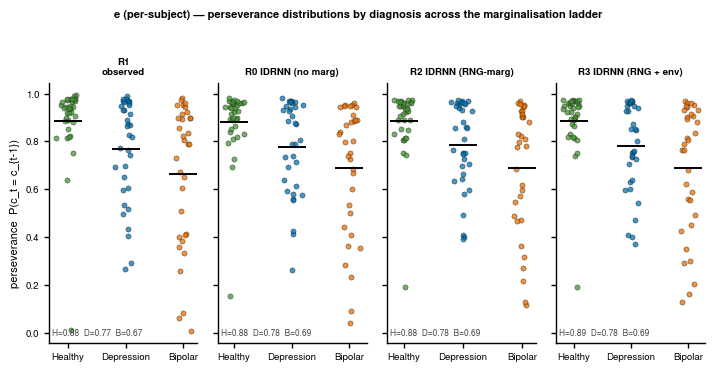

In [14]:
tr = np.load(os.path.join(BASE_DIR, 'three_regressions_dezfouli.npz'), allow_pickle=True)
diag = tr['diag']
METRICS = [
    ('R1\nobserved',          'R1_perseverance'),
    ('R0 IDRNN (no marg)',    'R0_idrnn_persev'),
    ('R2 IDRNN (RNG-marg)',   'R2_idrnn_persev'),
    ('R3 IDRNN (RNG + env)',  'R3_idrnn_persev'),
]

fig, axes = plt.subplots(1, 4, figsize=(DOUBLE_COL_IN, SINGLE_COL_IN), sharey=True)
rng = np.random.default_rng(13)
for ax, (label, key) in zip(axes, METRICS):
    x = tr[key].astype(float)
    for i, g in enumerate(DIAG_ORDER):
        m = (diag == g)
        if m.sum() == 0: continue
        ax.scatter(i + rng.normal(0, 0.07, m.sum()), x[m], s=14,
                   c=[COL_DIAG[g]], alpha=0.75,
                   edgecolors='black', linewidth=0.3)
        # group mean tick
        ax.scatter([i], [x[m].mean()], marker='_', s=400, c='black', linewidths=1.4)
    # Annotate group means
    means = [x[diag==g].mean() for g in DIAG_ORDER]
    ax.text(0.02, 0.02, f'H={means[0]:.2f}  D={means[1]:.2f}  B={means[2]:.2f}',
            transform=ax.transAxes, fontsize=6, ha='left', va='bottom', color='#444')
    ax.set_xticks(range(len(DIAG_ORDER)))
    ax.set_xticklabels(DIAG_ORDER, rotation=0, fontsize=7)
    ax.set_title(label, fontsize=7, fontweight='bold')
axes[0].set_ylabel('perseverance  P(c_t = c_{t-1})')
plt.suptitle('e (per-subject) — perseverance distributions by diagnosis across the marginalisation ladder',
             fontsize=8, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'panel_e_per_subject.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'panel_e_per_subject.pdf'),            bbox_inches='tight')
plt.show()

## Panel e (omnibus) — Bayesian one-way ANOVA across the marginalisation ladder

A single omnibus test per metric — *"do the three diagnosis groups differ at all in this perseverance measure?"* — rather than three separate pairwise contrasts. Bayesian one-way ANOVA via the BIC approximation:

$$\mathrm{BF}_{10} \approx \exp\!\big((\mathrm{BIC}_{\text{null}} - \mathrm{BIC}_{\text{alt}})/2\big), \qquad \mathrm{BIC} = n\log(\mathrm{SSE}/n) + p\log n,$$

with the **null** = a single grand mean (SSE over all subjects) and the **alternative** = per-group means (SSE pooled within groups). BF₁₀ > 3 = moderate evidence the groups differ, > 10 strong, > 100 decisive; < 1/3 = evidence for *no* difference.

Evaluated at four rungs of the marginalisation ladder — **R1** raw observed perseverance, **R0** one IDRNN rollout in the subject's exact environment (no marginalisation), **R2** averaged over RNG only, **R3** averaged over RNG *and* fresh environments.

**What we see:** the omnibus BF climbs monotonically R1 → R0 → R2 → R3 (≈ 12 → 24 → 30 → 39), all already strong. The group ordering is stable throughout — **Healthy most perseverative, Bipolar least (H > D > B)** — and the group *means* barely move; what rises is the *evidence*. Marginalising over RNG and then environment shrinks the within-group variance (e.g. Healthy SD 0.17 → 0.12) while leaving the between-group spread intact, so the same separation is measured with progressively less noise. That is the ladder's signature: rollouts denoise per-subject realisation/environment noise and **sharpen an already-present subject signature rather than manufacture one**. (Panel-e AUC barely moves across the ladder because subject *ranking* is already fixed by observed behaviour — the BF moves because the group means get cleaner, and Bayes factors are far more sensitive to that than AUC.)


R1_perseverance        omnibus BF10=   12.06 (12.1)   F= 7.40 p=0.001014   H/D/B mean=[0.885, 0.767, 0.666]
R0_idrnn_persev        omnibus BF10=    9.76 (9.76)   F= 7.17 p=0.001245   H/D/B mean=[0.882, 0.778, 0.687]
R2_idrnn_persev        omnibus BF10=   16.14 (16.1)   F= 7.73 p=0.0007641   H/D/B mean=[0.885, 0.783, 0.69]
R3_idrnn_persev        omnibus BF10=   20.80 (20.8)   F= 8.01 p=0.0005975   H/D/B mean=[0.887, 0.779, 0.687]


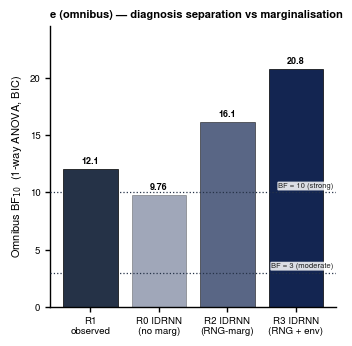

In [15]:
# ── Panel e (omnibus) — Bayesian one-way ANOVA BF10 across the marginalisation ladder ──
# ONE omnibus test per metric: "do the 3 diagnosis groups differ in this
# perseverance measure?" Bayesian one-way ANOVA via the BIC approximation:
#   BF10 ≈ exp((BIC_null − BIC_alt)/2),   BIC = n·log(SSE/n) + p·log(n)
# null = single grand mean; alt = per-group means. Tracks how the diagnosis
# signal sharpens as we marginalise over RNG (R0→R2) then environment (R2→R3).
from scipy.stats import f_oneway
tr = np.load(os.path.join(BASE_DIR, 'three_regressions_dezfouli.npz'), allow_pickle=True)
diag = tr['diag']
g_idx = np.where(diag == 'Healthy', 0, np.where(diag == 'Depression', 1, 2))

def omnibus_bf_anova(x, g):
    """Bayesian one-way ANOVA BF10 via the BIC approximation."""
    x = np.asarray(x, float); g = np.asarray(g, int)
    m = np.isfinite(x); x, g = x[m], g[m]
    n = len(x); K = len(np.unique(g))
    sse_null = ((x - x.mean())**2).sum()
    sse_alt  = sum(((x[g == k] - x[g == k].mean())**2).sum() for k in np.unique(g))
    bic_null = n*np.log(sse_null/n) + 2*np.log(n)        # grand mean + variance
    bic_alt  = n*np.log(sse_alt /n) + (K + 1)*np.log(n)  # K means + shared variance
    return float(np.exp((bic_null - bic_alt) / 2))

BARS = [
    ('R1\nobserved',          'R1_perseverance', COL_TRUE,  1.00),
    ('R0 IDRNN\n(no marg)',   'R0_idrnn_persev', COL_IDRNN, 0.40),
    ('R2 IDRNN\n(RNG-marg)',  'R2_idrnn_persev', COL_IDRNN, 0.70),
    ('R3 IDRNN\n(RNG + env)', 'R3_idrnn_persev', COL_IDRNN, 1.00),
]
bfs = []
for label, key, _, _ in BARS:
    x = tr[key].astype(float)
    bf = omnibus_bf_anova(x, g_idx)
    F, p = f_oneway(*[x[g_idx == k] for k in range(3)])
    means = [x[g_idx == k].mean() for k in range(3)]
    bfs.append(bf)
    print(f'{key:<22} omnibus BF10={bf:8.2f} ({fmt_bf(bf)})   F={F:5.2f} p={p:.4g}   '
          f'H/D/B mean={[round(v,3) for v in means]}')

fig, ax = plt.subplots(figsize=(SINGLE_COL_IN, SINGLE_COL_IN))
xs = np.arange(len(BARS))
for xi, (label, key, c, a), bf in zip(xs, BARS, bfs):
    ax.bar(xi, bf, color=c, alpha=a, edgecolor='black', linewidth=0.5, zorder=2)
ax.set_ylim(0, max(bfs) * 1.18)                       # linear y-axis
for lev, txt in [(3, 'BF = 3 (moderate)'), (10, 'BF = 10 (strong)')]:
    ax.axhline(lev, ls=':', color=COL_TRUE, lw=0.9, zorder=3)   # draw over the bars
    ax.text(len(BARS) - 0.45, lev + max(bfs) * 0.012, txt, ha='right', va='bottom',
            fontsize=5.5, color='#222222', zorder=6,
            bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.85))
for xi, bf in zip(xs, bfs):
    ax.text(xi, bf + max(bfs) * 0.015, fmt_bf(bf), ha='center', va='bottom', fontsize=6.5, fontweight='bold')
ax.set_xticks(xs); ax.set_xticklabels([l for l, _, _, _ in BARS], fontsize=7)
ax.set_ylabel('Omnibus BF$_{10}$  (1-way ANOVA, BIC)')
ax.set_title('e (omnibus) — diagnosis separation vs marginalisation', loc='left', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'panel_e_omnibus_bf.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'panel_e_omnibus_bf.pdf'), bbox_inches='tight')
plt.show()


## Panel e (omnibus, subject-bootstrap) — same test, Thalmann-style subject-level uncertainty

Structural twin of the Thalmann `poster_panel_bootc` panel b: for each of B=2000 bootstraps, resample the 101 subjects with replacement (**shared** `boot_idx` across all four R-conditions — so ΔlogBF pairs), then recompute the omnibus 1-way ANOVA BF₁₀ (Bayesian, BIC approximation) on the resampled cohort. Records:

- **Bar height** = point-estimate omnibus BF₁₀ (full 101 subjects) — same number the un-bootstrapped omnibus cell reports.
- **Error bar** = 2.5 / 97.5 percentiles of the 2000 bootstrap BFs.
- **Per-bar label** = `mean(BF_b) ± SD(BF_b)` on the log-linear axis (readable at all magnitudes).
- **Bracket** = paired posterior probability that R3's log₁₀BF exceeds R1's, converted to one-sided posterior-odds BF₁₀; a two-sided JZS BF₁₀ on the paired ΔlogBF is also reported.

No model refitting: subject bootstrap acts on the already-computed per-subject perseverance vectors (`R1_perseverance`, `R0_idrnn_persev`, `R2_idrnn_persev`, `R3_idrnn_persev`) from `three_regressions_dezfouli.npz`. This is the cheap "evaluation-set uncertainty" bootstrap; propagating training-set/rollout uncertainty would require re-running the R0/R2/R3 rollouts per bootstrap (hours of compute).


Stratified subject-level bootstrap: B=2000 × n=101 × 4 R-conditions (within-group resample; group sizes fixed at 34/34/33; shared boot idx → paired)


Per-bar omnibus BF₁₀: ['12.1', '9.76', '16.1', '20.8']

bar                        point R²    boot mean        SEM         SD
  R1_perseverance            0.1312       0.1475     0.0014     0.0622
  R0_idrnn_persev            0.1276       0.1425     0.0013     0.0585
  R2_idrnn_persev            0.1362       0.1507     0.0014     0.0607
  R3_idrnn_persev            0.1406       0.1552     0.0014     0.0610

ΔR² (R3 − R1) mean = +0.0077 ± 0.0128 (SD)
   P(R3 > R1) = 0.732
   one-sided posterior-odds BF₁₀ (R3 > R1) = 2.72


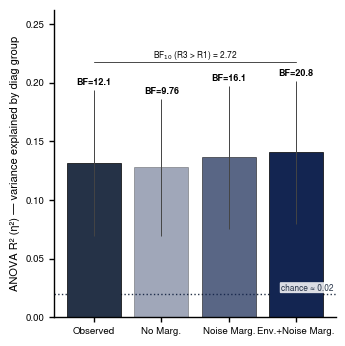

In [16]:
# ── Panel e (omnibus, subject-bootstrap) — ANOVA R² (η²) with one-sided directional BF ──
# Metric: R² = SS_between / SS_total = proportion of per-subject perseverance
# variance explained by diag group. Bounded [0, 1], well-behaved under
# bootstrap (no heavy tail).
# Uncertainty: subject-level bootstrap (B=2000, subjects with replacement,
# SHARED boot_idx across R1/R0/R2/R3 → paired ΔR² per bootstrap).
# Bracket test: one-sided BF₁₀ for R3 > R1 via posterior odds
# P(R3 > R1) / P(R3 ≤ R1) computed on the paired bootstrap ΔR² distribution.
# H0 expectation for R² under a truly null classifier is ≈ (K−1)/(N−1) with
# K=3 groups, N=101 → ≈ 0.02; dotted chance line drawn there.
from scipy.stats import f_oneway

B_BOOT = 2000
tr = np.load(os.path.join(BASE_DIR, 'three_regressions_dezfouli.npz'), allow_pickle=True)
diag = tr['diag']
g_idx = np.where(diag == 'Healthy', 0, np.where(diag == 'Depression', 1, 2))
n = len(g_idx)

def anova_r2(x, g):
    """One-way ANOVA R² (η²) = SS_between / SS_total."""
    x = np.asarray(x, float); g = np.asarray(g, int)
    m = np.isfinite(x); x, g = x[m], g[m]
    if len(x) < 4: return np.nan
    uniq = np.unique(g)
    if len(uniq) < 2: return np.nan
    ss_total = ((x - x.mean())**2).sum()
    if ss_total <= 0: return np.nan
    ss_within = sum(((x[g == k] - x[g == k].mean())**2).sum() for k in uniq)
    return float((ss_total - ss_within) / ss_total)

def omnibus_bf_bic(x, g):
    """BIC-approximated Bayesian one-way ANOVA BF₁₀ (matches the
    un-bootstrapped panel e (omnibus) cell). Computed once per bar
    on the full n=101 vector."""
    x = np.asarray(x, float); g = np.asarray(g, int)
    m = np.isfinite(x); x, g = x[m], g[m]
    if len(x) < 4: return float('nan')
    uniq = np.unique(g)
    if len(uniq) < 2 or any((g == k).sum() < 2 for k in uniq): return float('nan')
    n_local = len(x); K_local = len(uniq)
    sse_null = ((x - x.mean())**2).sum()
    sse_alt  = sum(((x[g == k] - x[g == k].mean())**2).sum() for k in uniq)
    if sse_null <= 0 or sse_alt <= 0: return float('nan')
    bic_null = n_local*np.log(sse_null/n_local) + 2*np.log(n_local)
    bic_alt  = n_local*np.log(sse_alt /n_local) + (K_local + 1)*np.log(n_local)
    return float(np.exp((bic_null - bic_alt) / 2))

BARS = [
    ('Observed',          'R1_perseverance', COL_TRUE,  1.00),
    ('No Marg.',          'R0_idrnn_persev', COL_IDRNN, 0.40),
    ('Noise Marg.',       'R2_idrnn_persev', COL_IDRNN, 0.70),
    ('Env.+Noise Marg.',  'R3_idrnn_persev', COL_IDRNN, 1.00),
]

# Stratified subject-level bootstrap: sample WITH REPLACEMENT within each
# diag group, keeping the exact 34/34/33 group balance in every draw.
# Conditional inference — answers "given the observed group sizes, how does
# R² fluctuate?" (narrower and cleaner than the uniform bootstrap, which lets
# the group counts drift).
rng = np.random.default_rng(4242)
groups = [np.where(g_idx == k)[0] for k in range(3)]
boot_idx = np.empty((B_BOOT, n), dtype=int)
for _b in range(B_BOOT):
    boot_idx[_b] = np.concatenate([rng.choice(gi, size=len(gi), replace=True) for gi in groups])
print(f'Stratified subject-level bootstrap: B={B_BOOT} × n={n} × 4 R-conditions '
      f'(within-group resample; group sizes fixed at 34/34/33; shared boot idx → paired)')

point_r2 = []; boot_r2s = []
for label, key, _, _ in BARS:
    x_full = tr[key].astype(float)
    point_r2.append(anova_r2(x_full, g_idx))
    b_arr = np.empty(B_BOOT)
    for b in range(B_BOOT):
        idx = boot_idx[b]
        b_arr[b] = anova_r2(x_full[idx], g_idx[idx])
    boot_r2s.append(b_arr)
# Per-bar omnibus BF₁₀ (BIC approximation, full n=101).
point_bf = [omnibus_bf_bic(tr[key].astype(float), g_idx) for _, key, _, _ in BARS]
print('Per-bar omnibus BF₁₀:', [fmt_bf(bf) for bf in point_bf])


# Paired ΔR² (R3 − R1) — the marginalisation-ladder directional hypothesis
delta_r2 = boot_r2s[3] - boot_r2s[0]
p_r3_gt_r1 = float((delta_r2 > 0).mean())
bf_one_side = (p_r3_gt_r1 / (1 - p_r3_gt_r1)) if 0 < p_r3_gt_r1 < 1 else \
              (float('inf') if p_r3_gt_r1 == 1 else 0.0)

# Bootstrap moments per bar (linear-scale — R² is well-behaved)
r2_mean = [float(np.nanmean(a))                       for a in boot_r2s]
r2_sem  = [float(np.nanstd(a, ddof=1) / np.sqrt(len(a))) for a in boot_r2s]
r2_sd   = [float(np.nanstd(a, ddof=1))                for a in boot_r2s]

# H0 chance line for R² (unbiased-under-null upward bias of η²)
chance_r2 = (3 - 1) / (n - 1)   # (K-1)/(N-1) with K=3 groups, N=n

print()
print(f'{"bar":<24} {"point R²":>10} {"boot mean":>12} {"SEM":>10} {"SD":>10}')
for (label, key, _, _), pt, bm, sem, sd in zip(BARS, point_r2, r2_mean, r2_sem, r2_sd):
    print(f'  {key:<22} {pt:10.4f} {bm:12.4f} {sem:10.4f} {sd:10.4f}')
print(f'\nΔR² (R3 − R1) mean = {np.nanmean(delta_r2):+.4f} ± {np.nanstd(delta_r2, ddof=1):.4f} (SD)')
print(f'   P(R3 > R1) = {p_r3_gt_r1:.3f}')
print(f'   one-sided posterior-odds BF₁₀ (R3 > R1) = {fmt_bf(bf_one_side)}')

# ── Plot: linear R² axis, matches the panel e omnibus aesthetic otherwise ─
fig, ax = plt.subplots(figsize=(SINGLE_COL_IN, SINGLE_COL_IN))
xs = np.arange(len(BARS))
labels = [l for l, _, _, _ in BARS]
colors = [c for _, _, c, _ in BARS]
alphas = [a for _, _, _, a in BARS]

for xi, pt, col, a in zip(xs, point_r2, colors, alphas):
    ax.bar(xi, pt, color=col, alpha=a, edgecolor='black', linewidth=0.5, zorder=2)
ax.errorbar(xs, point_r2, yerr=r2_sd, fmt='none',
            ecolor='#444444', elinewidth=0.7, capsize=0, zorder=3)

# Chance line
ax.axhline(chance_r2, ls=':', color=COL_TRUE, lw=1.0, zorder=1)
ax.text(len(BARS) - 0.45, chance_r2 + max(point_r2) * 0.01,
        f'chance ≈ {chance_r2:.2f}', ha='right', va='bottom',
        fontsize=6, color=COL_TRUE,
        bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.85))

# Per-bar point-estimate R² label
for xi, pt, sd, bf in zip(xs, point_r2, r2_sd, point_bf):
    ax.text(xi, pt + sd + max(point_r2) * 0.02, f'BF={fmt_bf(bf)}',
            ha='center', va='bottom', fontsize=6.5, fontweight='bold')

# R3-vs-R1 one-sided directional bracket
ymax = max(pt + sd for pt, sd in zip(point_r2, r2_sd))
bracket(ax, 0, 3, ymax + max(point_r2) * 0.10, max(point_r2) * 0.015,
        f'BF$_{{10}}$ (R3 > R1) = {fmt_bf(bf_one_side)}')

ax.set_ylim(0, max(pt + sd for pt, sd in zip(point_r2, r2_sd)) * 1.30)
ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel(r'ANOVA R² (η²) — variance explained by diag group')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'panel_e_omnibus_bootstrap.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT_DIR, 'panel_e_omnibus_bootstrap.pdf'),            bbox_inches='tight')
plt.show()

np.savez(os.path.join(OUT_DIR, 'panel_e_omnibus_bootstrap.npz'),
         boot_r2s=np.array(boot_r2s), point_r2=np.array(point_r2),
         boot_idx=boot_idx, delta_r2=delta_r2,
         chance_r2=chance_r2, point_bf=np.array(point_bf))


## Poster panel — combined (a · b · c)
Panel **a** held-out NLL per participant · **b** nested-bootstrap AUC gap (with per-class slope-graph) · **c** omnibus subject-bootstrap across the marginalisation ladder. Native subplots in one figure with uniform fonts/sizes (mirrors thalmann_results.ipynb::poster-panel-combined-code). Body of each panel is a verbatim mirror of the corresponding standalone cell, so any tweak there flows into this composite once the composite is re-executed.


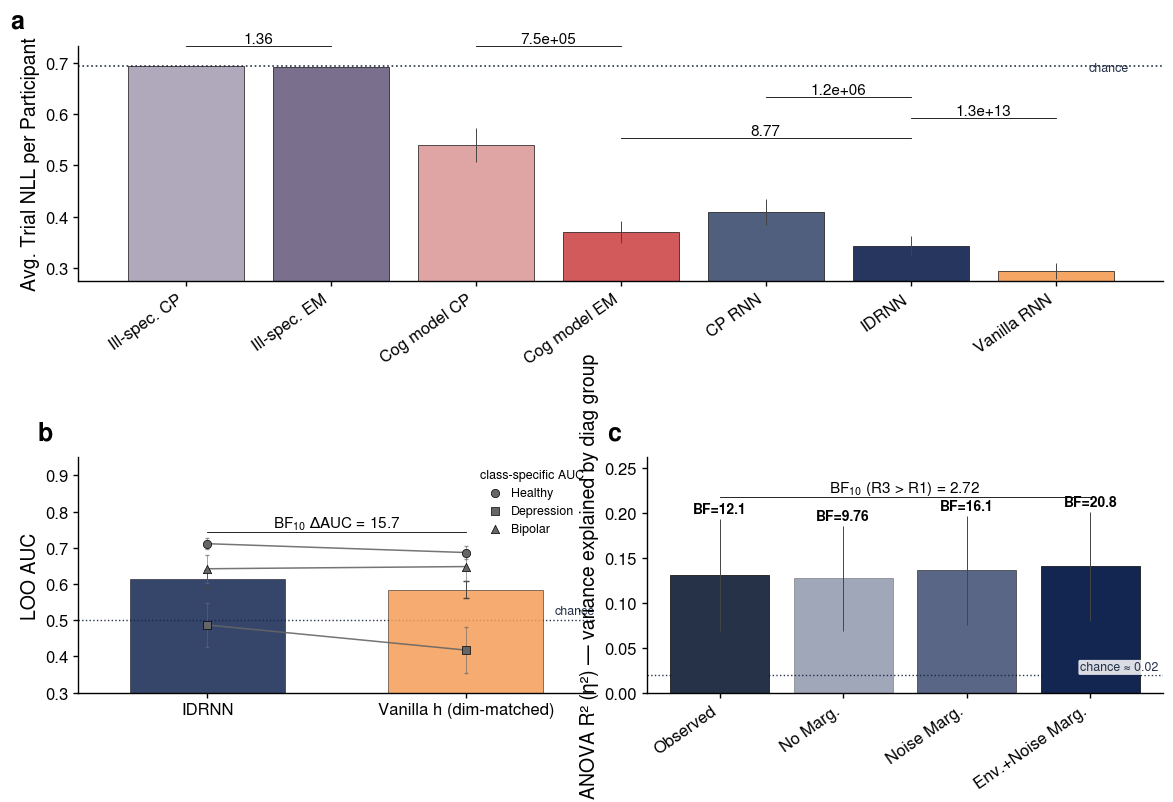

Saved -> final_plots/dezfouli_z3_full/publication_figure/poster_panel.{png,pdf,svg}


In [17]:
# === POSTER PANEL — a (NLL, top row) · b (nested-boot AUC) · c (omnibus subject-boot R²) ===
# NATIVE subplots in ONE figure so the font family and every font size are
# identical across panels. Mirrors thalmann_results.ipynb::poster-panel-combined-code:
# GridSpec, POSTER_RC typography, _bracket helper. Panel bodies are verbatim
# mirrors of the standalone panel-a-code, panel-b-nested-code, and
# panele-omni-boot-code cells (any edit there flows here on re-execute).
# Layout: Panel a full-width top row, Panel b + Panel c side-by-side below.
import matplotlib.gridspec as gridspec

FS_BASE, FS_LABEL, FS_TICK, FS_ANNOT, FS_LETTER = 13, 14, 12, 11, 18
POSTER_RC = {
    "font.size":        FS_BASE,
    "axes.titlesize":   FS_BASE,
    "axes.labelsize":   FS_LABEL,
    "xtick.labelsize":  FS_TICK,
    "ytick.labelsize":  FS_TICK,
    "legend.fontsize":  FS_ANNOT,
    "mathtext.default": "regular",
}

def _bracket(ax, x1, x2, y, h, txt, fs=FS_ANNOT):
    ax.plot([x1, x2], [y + h, y + h], lw=0.6, c="black")
    ax.text((x1 + x2) / 2, y + h * 1.1, txt, ha="center", va="bottom", fontsize=fs)

with plt.rc_context(POSTER_RC):
    fig = plt.figure(figsize=(14, 8.4))
    gs = gridspec.GridSpec(2, 12, figure=fig, height_ratios=[1.0, 1.0],
                           hspace=0.75, wspace=1.2)
    ax_a = fig.add_subplot(gs[0, 0:12])
    ax_b = fig.add_subplot(gs[1, 0:6])
    ax_c = fig.add_subplot(gs[1, 6:12])

    # ============================================================ Panel a: NLL
    df_a = pd.read_csv(os.path.join(BASE_DIR, "per_participant_nll.csv"))
    KEYS_COLS_a = [
        ("nll_ill_cp",  "Ill-spec. CP",  COL_Q_CP),
        ("nll_ill_em",  "Ill-spec. EM",  COL_Q_EM),
        ("nll_cog_cp",  "Cog model CP",  COL_FQ_CP),
        ("nll_cog_em",  "Cog model EM",  COL_FQ_EM),
        ("nll_cp_rnn",  "CP RNN",        COL_RNN_CP),
        ("nll_idrnn",   "IDRNN",         COL_IDRNN),
        ("nll_vanilla", "Vanilla RNN",   COL_VANILLA),
    ]
    labels_a = [l for _, l, _ in KEYS_COLS_a]
    cols_a   = [c for _, _, c in KEYS_COLS_a]
    means_a  = [df_a[k].mean() for k, _, _ in KEYS_COLS_a]
    sems_a   = [stats.sem(df_a[k].dropna()) for k, _, _ in KEYS_COLS_a]
    xs_a     = np.arange(len(labels_a))
    chance_a = float(np.log(2))
    bf_Q_a           = paired_bf(df_a["nll_ill_cp"],  df_a["nll_ill_em"])
    bf_FQ_a          = paired_bf(df_a["nll_cog_cp"],  df_a["nll_cog_em"])
    bf_RNNCP_IDRNN_a = paired_bf(df_a["nll_cp_rnn"],  df_a["nll_idrnn"])
    bf_Van_IDRNN_a   = paired_bf(df_a["nll_vanilla"], df_a["nll_idrnn"])
    bf_cogEM_IDRNN_a = paired_bf(df_a["nll_cog_em"],  df_a["nll_idrnn"])

    ax_a.bar(xs_a, means_a, color=cols_a, alpha=0.92, edgecolor="black",
             linewidth=0.5, zorder=2)
    ax_a.errorbar(xs_a, means_a, yerr=sems_a, fmt="none", ecolor="#444444",
                  elinewidth=0.7, capsize=0, zorder=3)
    ax_a.axhline(chance_a, ls=":", color=COL_TRUE, lw=1.2, zorder=1)
    ax_a.text(len(xs_a)-0.5, chance_a-0.015, "chance", ha="right", va="bottom",
              fontsize=FS_ANNOT-2, color=COL_TRUE)
    ymax_a = max(means_a) + max(sems_a)
    h_step_a = 0.05 * (chance_a - min(means_a))
    yb_a = ymax_a + h_step_a
    _bracket(ax_a, 0, 1, yb_a - 0.02,                     h_step_a * 0.3, fmt_bf(bf_Q_a))
    _bracket(ax_a, 2, 3, yb_a - 0.02,                     h_step_a * 0.3, fmt_bf(bf_FQ_a))
    _bracket(ax_a, 4, 5, yb_a - 5*h_step_a - 0.02,        h_step_a * 0.3, fmt_bf(bf_RNNCP_IDRNN_a))
    _bracket(ax_a, 5, 6, yb_a - h_step_a * 7 - 0.02,      h_step_a * 0.3, fmt_bf(bf_Van_IDRNN_a))
    _bracket(ax_a, 3, 5, yb_a - 9 * h_step_a - 0.02,      h_step_a * 0.3, fmt_bf(bf_cogEM_IDRNN_a))
    ax_a.set_xticks(xs_a); ax_a.set_xticklabels(labels_a, rotation=35, ha="right")
    ax_a.set_ylabel("Avg. Trial NLL per Participant")
    ax_a.set_ylim(bottom=min(means_a) - 0.02, top=chance_a + 2 * h_step_a)

    # ============================================================ Panel b: nested-bootstrap AUC
    _cache_b = os.path.join(OUT_DIR, "panel_b_nested_bootstrap.npz")
    assert os.path.exists(_cache_b), "panel_b_nested_bootstrap.npz missing — run the standalone cell first"
    _zb = np.load(_cache_b)
    aucs_i_boot = _zb["aucs_idrnn"]; aucs_v_boot = _zb["aucs_vanilla"]
    aucs_i_cls  = _zb["aucs_idrnn_per_class"]; aucs_v_cls = _zb["aucs_vanilla_per_class"]
    delta_boot  = _zb["delta"]
    B_used_b = int(aucs_i_boot.shape[0])
    z_dim_idr = int(np.load(os.path.join(BASE_DIR, "canonical/idrnn/all_30_step1_z.npy")).shape[2])
    n_b = len(pd.read_csv(os.path.join(BASE_DIR, "per_participant_nll.csv")))

    mean_i_b, sd_i_b = float(np.nanmean(aucs_i_boot)), float(np.nanstd(aucs_i_boot, ddof=1))
    mean_v_b, sd_v_b = float(np.nanmean(aucs_v_boot)), float(np.nanstd(aucs_v_boot, ddof=1))
    per_class_mean_i = np.nanmean(aucs_i_cls, axis=0)
    per_class_mean_v = np.nanmean(aucs_v_cls, axis=0)
    per_class_sd_i   = np.nanstd(aucs_i_cls, axis=0, ddof=1)
    per_class_sd_v   = np.nanstd(aucs_v_cls, axis=0, ddof=1)
    dmean_b = float(np.nanmean(delta_boot)); dsd_b = float(np.nanstd(delta_boot, ddof=1))
    p_pos_b = float((delta_boot > 0).mean())
    bf_one_b = (p_pos_b / (1 - p_pos_b)) if 0 < p_pos_b < 1 else (float("inf") if p_pos_b == 1 else 0.0)

    xs_b = np.array([0.0, 1.0]); w_b = 0.6
    ax_b.bar(xs_b, [mean_i_b, mean_v_b], w_b,
             color=[COL_IDRNN, COL_VANILLA],
             edgecolor="black", linewidth=0.4, alpha=0.85, zorder=2)
    ax_b.errorbar(xs_b, [mean_i_b, mean_v_b], yerr=[sd_i_b, sd_v_b],
                  fmt="none", ecolor="#444444", elinewidth=0.7, capsize=2.5, zorder=3)
    ax_b.axhline(0.5, ls=":", color=COL_TRUE, lw=1.0, zorder=1)
    ax_b.text(1.5, 0.508, "chance", ha="right", va="bottom",
              fontsize=FS_ANNOT-2, color=COL_TRUE)

    markers_b = ["o", "s", "^"]
    _CLS_GREY = "#666666"
    for c_, lab in enumerate(DIAG_ORDER):
        yv = [per_class_mean_i[c_], per_class_mean_v[c_]]
        ax_b.plot(xs_b, yv, color=_CLS_GREY, lw=1.1, alpha=0.9, zorder=4)
        ax_b.errorbar(xs_b, yv,
                      yerr=[per_class_sd_i[c_], per_class_sd_v[c_]],
                      fmt="none", ecolor=_CLS_GREY, elinewidth=0.6, capsize=1.5,
                      alpha=0.7, zorder=4)
        ax_b.scatter(xs_b, yv, marker=markers_b[c_], s=36, c=_CLS_GREY,
                     edgecolor="black", linewidth=0.5, zorder=6, label=lab)
    ax_b.legend(loc="upper right", frameon=False, fontsize=FS_ANNOT-2, handlelength=1,
                title="class-specific AUC", title_fontsize=FS_ANNOT-2)

    ymax_b = max(mean_i_b + sd_i_b, mean_v_b + sd_v_b,
                 per_class_mean_i.max(), per_class_mean_v.max())
    h_step_b = 0.025
    _bracket(ax_b, 0, 1, ymax_b + h_step_b, h_step_b * 0.3,
             f"BF$_{{10}}$ ΔAUC = {fmt_bf(bf_one_b)}")
    ax_b.set_xticks(xs_b); ax_b.set_xticklabels(["IDRNN", "Vanilla h (dim-matched)"])
    ax_b.set_xlim(-0.5, 1.5)
    ax_b.set_ylabel("LOO AUC")
    ax_b.set_ylim(0.3, 0.95)

    # ============================================================ Panel c: subject-bootstrap ANOVA R²
    _cache_c = os.path.join(OUT_DIR, "panel_e_omnibus_bootstrap.npz")
    assert os.path.exists(_cache_c), "panel_e_omnibus_bootstrap.npz missing — run the standalone cell first"
    _zc = np.load(_cache_c)
    assert "boot_r2s" in _zc.files, "cache is stale — rerun the standalone cell (it now saves R² rather than BFs)"
    boot_r2s_c   = _zc["boot_r2s"]        # shape (4, B_BOOT)
    point_r2_c   = _zc["point_r2"]
    delta_r2_c   = _zc["delta_r2"]
    chance_r2_c  = float(_zc["chance_r2"])
    point_bf_c   = _zc["point_bf"] if "point_bf" in _zc.files else np.full(4, np.nan)

    r2_sd_c = [float(np.nanstd(a, ddof=1)) for a in boot_r2s_c]
    p_pos_c  = float((delta_r2_c > 0).mean())
    bf_one_c = (p_pos_c / (1 - p_pos_c)) if 0 < p_pos_c < 1 else (float("inf") if p_pos_c == 1 else 0.0)

    LABELS_C = ["Observed", "No Marg.", "Noise Marg.", "Env.+Noise Marg."]
    COLORS_C = [COL_TRUE, COL_IDRNN, COL_IDRNN, COL_IDRNN]
    ALPHAS_C = [1.00, 0.40, 0.70, 1.00]
    xs_c = np.arange(len(LABELS_C))

    for xi, pt, col, a in zip(xs_c, point_r2_c, COLORS_C, ALPHAS_C):
        ax_c.bar(xi, pt, color=col, alpha=a, edgecolor="black", linewidth=0.5, zorder=2)
    ax_c.errorbar(xs_c, point_r2_c, yerr=r2_sd_c, fmt="none",
                  ecolor="#444444", elinewidth=0.7, capsize=0, zorder=3)

    ax_c.axhline(chance_r2_c, ls=":", color=COL_TRUE, lw=1.0, zorder=1)
    ax_c.text(len(LABELS_C) - 0.45, chance_r2_c + max(point_r2_c) * 0.01,
              f"chance ≈ {chance_r2_c:.2f}", ha="right", va="bottom",
              fontsize=FS_ANNOT-2, color=COL_TRUE,
              bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.85))

    for xi, pt, sd, bf in zip(xs_c, point_r2_c, r2_sd_c, point_bf_c):
        ax_c.text(xi, pt + sd + max(point_r2_c) * 0.02, f"BF={fmt_bf(bf)}",
                  ha="center", va="bottom", fontsize=FS_ANNOT-1, fontweight="bold")

    ymax_c = max(pt + sd for pt, sd in zip(point_r2_c, r2_sd_c))
    _bracket(ax_c, 0, 3, ymax_c + max(point_r2_c) * 0.10,
             max(point_r2_c) * 0.015, f"BF$_{{10}}$ (R3 > R1) = {fmt_bf(bf_one_c)}")

    ax_c.set_ylim(0, max(pt + sd for pt, sd in zip(point_r2_c, r2_sd_c)) * 1.30)
    ax_c.set_xticks(xs_c); ax_c.set_xticklabels(LABELS_C, rotation=35, ha="right")
    ax_c.set_ylabel(r"ANOVA R² (η²) — variance explained by diag group")

    # Panel letters (poster convention)
    for ax, txt in [(ax_a, "a"), (ax_b, "b"), (ax_c, "c")]:
        ax.text(-0.05, 1.05, txt, transform=ax.transAxes,
                fontsize=FS_LETTER, fontweight="bold", va="bottom", ha="right")

    plt.savefig(os.path.join(OUT_DIR, "poster_panel.png"), dpi=600, bbox_inches="tight")
    plt.savefig(os.path.join(OUT_DIR, "poster_panel.pdf"),            bbox_inches="tight")
    plt.savefig(os.path.join(OUT_DIR, "poster_panel.svg"),            bbox_inches="tight")
    plt.show()

print("Saved -> " + os.path.join(OUT_DIR, "poster_panel.{png,pdf,svg}"))


## Journal figure — half-width combined (a · b · c)
Nature Human Behaviour half-width composite mirroring `thalmann_results.ipynb::cell 88`. Uses `W_HALF = 90 mm` (half of NHB's 180 mm double-column max) and journal typography (`FS_BASE=6 … FS_LETTER=8`). Suitable for `wrapfigure` integration in single-column Overleaf drafts. Reads the same caches as the poster panel — Panel a's per-participant NLL CSV, Panel b's nested-bootstrap npz, Panel c's stratified-bootstrap R² npz. Saved as `final_plots/.../dezfouli_combined_journal_half.{png,pdf,svg}` at dpi=600, WITHOUT `bbox_inches="tight"` so figsize stays authoritative under the constrained-layout engine.


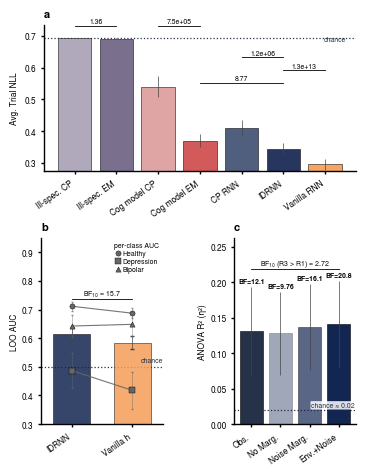

Saved -> final_plots/dezfouli_z3_full/publication_figure/dezfouli_combined_journal_half.png / .pdf / .svg


In [18]:
# === DEZFOULI COMBINED JOURNAL FIGURE (Nature Human Behaviour, half-width) ===
# Composite of Panel a (NLL) · Panel b (nested-boot AUC) · Panel c (omnibus R²).
# Layout: Panel a on the top row (full width), Panels b + c side by side beneath.
# Convention exactly matches thalmann_results.ipynb::cell 88 (id ba89d947): NHB
# max width 180 mm halved to 90 mm; journal fonts 5–8 pt via JOURNAL_RC/rc_context;
# saved WITHOUT bbox_inches="tight" so figsize stays authoritative under the
# constrained-layout engine. Emits .png/.pdf/.svg at 600 dpi.
import matplotlib.gridspec as gridspec

MM = 1 / 25.4
W_HALF = 90 * MM              # NHB half of double-column max (180 mm)

FS_BASE, FS_LABEL, FS_TICK, FS_ANNOT, FS_LETTER = 6, 6, 6, 5, 8
JOURNAL_RC = {
    "font.size":        FS_BASE,
    "axes.titlesize":   FS_BASE,
    "axes.labelsize":   FS_LABEL,
    "xtick.labelsize":  FS_TICK,
    "ytick.labelsize":  FS_TICK,
    "legend.fontsize":  FS_ANNOT,
    "mathtext.default": "regular",
}

def _bracket(ax, x1, x2, y, h, txt, fs=FS_ANNOT):
    ax.plot([x1, x2], [y + h, y + h], lw=0.6, c="black")
    ax.text((x1 + x2) / 2, y + h * 1.1, txt, ha="center", va="bottom", fontsize=fs)

# ── Preload panel data ────────────────────────────────────────────────────
df_a = pd.read_csv(os.path.join(BASE_DIR, "per_participant_nll.csv"))
KEYS_COLS_a = [
    ("nll_ill_cp",  "Ill-spec. CP",  COL_Q_CP),
    ("nll_ill_em",  "Ill-spec. EM",  COL_Q_EM),
    ("nll_cog_cp",  "Cog model CP",  COL_FQ_CP),
    ("nll_cog_em",  "Cog model EM",  COL_FQ_EM),
    ("nll_cp_rnn",  "CP RNN",        COL_RNN_CP),
    ("nll_idrnn",   "IDRNN",         COL_IDRNN),
    ("nll_vanilla", "Vanilla RNN",   COL_VANILLA),
]

_cache_b = os.path.join(OUT_DIR, "panel_b_nested_bootstrap.npz")
_cache_c = os.path.join(OUT_DIR, "panel_e_omnibus_bootstrap.npz")
assert os.path.exists(_cache_b), "panel_b_nested_bootstrap.npz missing — run the standalone cell first"
assert os.path.exists(_cache_c), "panel_e_omnibus_bootstrap.npz missing — run the standalone cell first"

_zb = np.load(_cache_b)
aucs_i_boot = _zb["aucs_idrnn"]; aucs_v_boot = _zb["aucs_vanilla"]
aucs_i_cls  = _zb["aucs_idrnn_per_class"]; aucs_v_cls = _zb["aucs_vanilla_per_class"]
delta_boot  = _zb["delta"]

_zc = np.load(_cache_c)
boot_r2s_c   = _zc["boot_r2s"]
point_r2_c   = _zc["point_r2"]
delta_r2_c   = _zc["delta_r2"]
chance_r2_c  = float(_zc["chance_r2"])
point_bf_c   = _zc["point_bf"] if "point_bf" in _zc.files else np.full(4, np.nan)

# ── Figure ────────────────────────────────────────────────────────────────
with plt.rc_context(JOURNAL_RC):
    fig = plt.figure(figsize=(W_HALF, 4.6), constrained_layout=True)
    fig.get_layout_engine().set(h_pad=0.02, hspace=0, wspace=0)
    # Row 2 (panels b + c) gets a substantially larger allocation so its
    # data axes match panel a's after panel a's long 35° xlabels eat their share.
    outer = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.7])

    ax_a = fig.add_subplot(outer[0, 0])
    gs_bc = outer[1, 0].subgridspec(1, 100, wspace=0.0)
    ax_b = fig.add_subplot(gs_bc[0, 0:45])
    ax_c = fig.add_subplot(gs_bc[0, 55:100])

    # ============================================================ Panel a: NLL
    labels_a = [l for _, l, _ in KEYS_COLS_a]
    cols_a   = [c for _, _, c in KEYS_COLS_a]
    means_a  = [df_a[k].mean() for k, _, _ in KEYS_COLS_a]
    sems_a   = [stats.sem(df_a[k].dropna()) for k, _, _ in KEYS_COLS_a]
    xs_a     = np.arange(len(labels_a))
    chance_a = float(np.log(2))
    bf_Q_a           = paired_bf(df_a["nll_ill_cp"],  df_a["nll_ill_em"])
    bf_FQ_a          = paired_bf(df_a["nll_cog_cp"],  df_a["nll_cog_em"])
    bf_RNNCP_IDRNN_a = paired_bf(df_a["nll_cp_rnn"],  df_a["nll_idrnn"])
    bf_Van_IDRNN_a   = paired_bf(df_a["nll_vanilla"], df_a["nll_idrnn"])
    bf_cogEM_IDRNN_a = paired_bf(df_a["nll_cog_em"],  df_a["nll_idrnn"])

    ax_a.bar(xs_a, means_a, color=cols_a, alpha=0.92, edgecolor="black",
             linewidth=0.4, zorder=2)
    ax_a.errorbar(xs_a, means_a, yerr=sems_a, fmt="none", ecolor="#444444",
                  elinewidth=0.5, capsize=0, zorder=3)
    ax_a.axhline(chance_a, ls=":", color=COL_TRUE, lw=0.9, zorder=1)
    ax_a.text(len(xs_a) - 0.5, chance_a - 0.015, "chance", ha="right", va="bottom",
              fontsize=FS_ANNOT, color=COL_TRUE)
    ymax_a = max(means_a) + max(sems_a)
    h_step_a = 0.05 * (chance_a - min(means_a))
    yb_a = ymax_a + h_step_a
    _bracket(ax_a, 0, 1, yb_a - 0.02,                    h_step_a * 0.3, fmt_bf(bf_Q_a))
    _bracket(ax_a, 2, 3, yb_a - 0.02,                    h_step_a * 0.3, fmt_bf(bf_FQ_a))
    _bracket(ax_a, 4, 5, yb_a - 5 * h_step_a - 0.02,     h_step_a * 0.3, fmt_bf(bf_RNNCP_IDRNN_a))
    _bracket(ax_a, 5, 6, yb_a - h_step_a * 7 - 0.02,     h_step_a * 0.3, fmt_bf(bf_Van_IDRNN_a))
    _bracket(ax_a, 3, 5, yb_a - 9 * h_step_a - 0.02,     h_step_a * 0.3, fmt_bf(bf_cogEM_IDRNN_a))
    ax_a.set_xticks(xs_a); ax_a.set_xticklabels(labels_a, rotation=35, ha="right")
    ax_a.set_ylabel("Avg. Trial NLL")
    ax_a.set_ylim(bottom=min(means_a) - 0.02, top=chance_a + 2 * h_step_a)
    ax_a.tick_params(length=2)

    # ============================================================ Panel b: nested-bootstrap AUC
    mean_i_b, sd_i_b = float(np.nanmean(aucs_i_boot)), float(np.nanstd(aucs_i_boot, ddof=1))
    mean_v_b, sd_v_b = float(np.nanmean(aucs_v_boot)), float(np.nanstd(aucs_v_boot, ddof=1))
    per_class_mean_i = np.nanmean(aucs_i_cls, axis=0)
    per_class_mean_v = np.nanmean(aucs_v_cls, axis=0)
    per_class_sd_i   = np.nanstd(aucs_i_cls, axis=0, ddof=1)
    per_class_sd_v   = np.nanstd(aucs_v_cls, axis=0, ddof=1)
    p_pos_b = float((delta_boot > 0).mean())
    bf_one_b = (p_pos_b / (1 - p_pos_b)) if 0 < p_pos_b < 1 else (float("inf") if p_pos_b == 1 else 0.0)

    xs_b = np.array([0.0, 1.0]); w_b = 0.6
    ax_b.bar(xs_b, [mean_i_b, mean_v_b], w_b,
             color=[COL_IDRNN, COL_VANILLA],
             edgecolor="black", linewidth=0.4, alpha=0.85, zorder=2)
    ax_b.errorbar(xs_b, [mean_i_b, mean_v_b], yerr=[sd_i_b, sd_v_b],
                  fmt="none", ecolor="#444444", elinewidth=0.5, capsize=1.5, zorder=3)
    ax_b.axhline(0.5, ls=":", color=COL_TRUE, lw=0.9, zorder=1)
    ax_b.text(1.5, 0.508, "chance", ha="right", va="bottom",
              fontsize=FS_ANNOT, color=COL_TRUE)

    markers_b = ["o", "s", "^"]
    _CLS_GREY = "#666666"
    for c_, lab in enumerate(DIAG_ORDER):
        yv = [per_class_mean_i[c_], per_class_mean_v[c_]]
        ax_b.plot(xs_b, yv, color=_CLS_GREY, lw=0.8, alpha=0.9, zorder=4)
        ax_b.errorbar(xs_b, yv,
                      yerr=[per_class_sd_i[c_], per_class_sd_v[c_]],
                      fmt="none", ecolor=_CLS_GREY, elinewidth=0.4, capsize=1.0,
                      alpha=0.7, zorder=4)
        ax_b.scatter(xs_b, yv, marker=markers_b[c_], s=14, c=_CLS_GREY,
                     edgecolor="black", linewidth=0.3, zorder=6, label=lab)
    ax_b.legend(loc="upper right", frameon=False, fontsize=FS_ANNOT, handlelength=0.8,
                title="per-class AUC", title_fontsize=FS_ANNOT,
                borderaxespad=0.2, handletextpad=0.3, labelspacing=0.15)

    ymax_b = max(mean_i_b + sd_i_b, mean_v_b + sd_v_b,
                 per_class_mean_i.max(), per_class_mean_v.max())
    h_step_b = 0.02
    _bracket(ax_b, 0, 1, ymax_b + h_step_b, h_step_b * 0.3,
             f"BF$_{{10}}$ = {fmt_bf(bf_one_b)}")
    ax_b.set_xticks(xs_b); ax_b.set_xticklabels(["IDRNN", "Vanilla h"], rotation=35, ha="right")
    ax_b.set_xlim(-0.5, 1.5)
    ax_b.set_ylabel("LOO AUC", labelpad=2)
    ax_b.set_ylim(0.3, 0.95)
    ax_b.tick_params(length=2)

    # ============================================================ Panel c: subject-bootstrap ANOVA R²
    r2_sd_c = [float(np.nanstd(a, ddof=1)) for a in boot_r2s_c]
    p_pos_c = float((delta_r2_c > 0).mean())
    bf_one_c = (p_pos_c / (1 - p_pos_c)) if 0 < p_pos_c < 1 else (float("inf") if p_pos_c == 1 else 0.0)

    LABELS_C = ["Obs.", "No Marg.", "Noise Marg.", "Env.+Noise"]
    COLORS_C = [COL_TRUE, COL_IDRNN, COL_IDRNN, COL_IDRNN]
    ALPHAS_C = [1.00, 0.40, 0.70, 1.00]
    xs_c = np.arange(len(LABELS_C))

    for xi, pt, col, a in zip(xs_c, point_r2_c, COLORS_C, ALPHAS_C):
        ax_c.bar(xi, pt, color=col, alpha=a, edgecolor="black", linewidth=0.4, zorder=2)
    ax_c.errorbar(xs_c, point_r2_c, yerr=r2_sd_c, fmt="none",
                  ecolor="#444444", elinewidth=0.5, capsize=0, zorder=3)
    ax_c.axhline(chance_r2_c, ls=":", color=COL_TRUE, lw=0.9, zorder=1)
    ax_c.text(len(LABELS_C) - 0.45, chance_r2_c + max(point_r2_c) * 0.01,
              f"chance ≈ {chance_r2_c:.2f}", ha="right", va="bottom",
              fontsize=FS_ANNOT, color=COL_TRUE,
              bbox=dict(boxstyle="round,pad=0.10", fc="white", ec="none", alpha=0.85))

    for xi, pt, sd, bf in zip(xs_c, point_r2_c, r2_sd_c, point_bf_c):
        ax_c.text(xi, pt + sd + max(point_r2_c) * 0.02, f"BF={fmt_bf(bf)}",
                  ha="center", va="bottom", fontsize=FS_ANNOT, fontweight="bold")

    ymax_c = max(pt + sd for pt, sd in zip(point_r2_c, r2_sd_c))
    _bracket(ax_c, 0, 3, ymax_c + max(point_r2_c) * 0.10,
             max(point_r2_c) * 0.015, f"BF$_{{10}}$ (R3 > R1) = {fmt_bf(bf_one_c)}")

    ax_c.set_ylim(0, max(pt + sd for pt, sd in zip(point_r2_c, r2_sd_c)) * 1.30)
    ax_c.set_xticks(xs_c); ax_c.set_xticklabels(LABELS_C, rotation=35, ha="right")
    ax_c.set_ylabel(r"ANOVA R² (η²)", labelpad=2)
    ax_c.tick_params(length=2)

    # ── Panel letters (Thalmann/journal convention) ──────────────────────
    for ax, txt in [(ax_a, "a"), (ax_b, "b"), (ax_c, "c")]:
        ax.set_title(txt, loc="left", fontweight="bold", fontsize=FS_LETTER)

    out_base = os.path.join(OUT_DIR, "dezfouli_combined_journal_half")
    fig.savefig(out_base + ".png", dpi=600)
    fig.savefig(out_base + ".pdf")
    fig.savefig(out_base + ".svg")
    plt.show()

print(f"Saved -> {out_base}.png / .pdf / .svg")
